# 그래픽카드 활성화

In [ ]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"\n✅ 드디어 찾았습니다! 사용 가능한 GPU: {len(gpus)}개")
    for gpu in gpus:
        # GPU 이름과 메모리 정보 출력
        details = tf.config.experimental.get_device_details(gpu)
        print(f"  - Device: {details.get('device_name', 'N/A')}")
else:
    print("\n❌ 아직 GPU를 찾을 수 없습니다. 처음부터 다시 확인해주세요.")

TensorFlow Version: 2.10.0

✅ 드디어 찾았습니다! 사용 가능한 GPU: 1개
  - Device: NVIDIA GeForce RTX 3070 Ti


In [ ]:
# GPU 활용 준비

import tensorflow as tf
import os

# 1. GPU 장치 확인 및 메모리 성장 설정
# 사용 가능한 GPU 목록을 가져옵니다.
gpus = tf.config.list_physical_devices('GPU')

if gpus:
  try:
    # 현재는 단일 GPU 사용을 가정하지만, 여러 GPU가 있을 경우를 대비해 반복문으로 설정합니다.
    for gpu in gpus:
      # GPU 메모리 성장을 활성화합니다.
      # 이 설정을 통해 TensorFlow는 필요한 만큼만 GPU 메모리를 점진적으로 할당하여
      # 메모리 부족으로 인한 오류를 예방할 수 있습니다.
      tf.config.experimental.set_memory_growth(gpu, True)

    # 첫 번째 GPU를 논리적으로 기본 장치로 설정합니다.
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(f"✅ 사용 가능한 GPU: {len(gpus)}개, 논리적 GPU: {len(logical_gpus)}개")
    print("GPU 메모리 성장(Memory Growth) 설정을 완료했습니다.")

  except RuntimeError as e:
    # 프로그램 시작 후에는 메모리 성장 설정을 변경할 수 없으므로, try-except로 처리합니다.
    print("❌ 런타임 오류:", e)
else:
  print("⚠️ 경고: 사용 가능한 GPU를 찾을 수 없습니다. CPU로 훈련을 진행합니다.")
  print("CUDA와 cuDNN 설치, 그리고 그래픽 드라이버 버전을 확인해주세요.")


# 2. 로깅 정보 수준 설정 (선택 사항)
# TensorFlow의 기본 로그 메시지를 조절하여 터미널을 깔끔하게 유지할 수 있습니다.
# '0' (기본값): 모든 정보 표시
# '1': INFO 메시지 제외
# '2': INFO, WARNING 메시지 제외
# '3': INFO, WARNING, ERROR 메시지 제외
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

✅ 사용 가능한 GPU: 1개, 논리적 GPU: 1개
GPU 메모리 성장(Memory Growth) 설정을 완료했습니다.


In [ ]:
!pip install category_encoders

  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 8.9/8.9 MB 46.2 MB/s eta 0:00:00
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ------------------------------- -------- 12.3/15.8 MB 64.5 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 55.3 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 2.2.0

    Uninstalling threadpoolctl-2.2.0:

   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpool

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 1.26.4 which is incompatible.


In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 마이너스 부호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

# 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 데이터 전처리 코드

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 사전설정
import pandas as pd
import numpy as np

# 아이템과 아이템코드 설정
item = '무'
item_code = 601
gdrive_data = '/content/drive/MyDrive/박진성/datasets/'
gdrive_model = '/content/drive/MyDrive/박진성/models/'
file_path = f'{item}_월차낼게요.csv'

# 양파 : 1201 # 배추 : 1001 # 상추 : 1005 # 사과 : 0601 # 무 : 1101 # 감자 : 0501 # 대파 : 1202 # 건고추 : 1207
# 마늘 : 1209 # 딸기 : 0804  # 방울토마토 : 0806 # 오이 : 0901 # 양배추 : 1004  # 고구마 : 0502  # 배 : 0602

,year,week,week_start,품종코드,등급코드,직팜산지코드,총거래량(kg),일평균기온,최고기온,최저기온,...,최저기온_t-2,평균상대습도_t-2,강수량(mm)_t-2,1시간최고강수량(mm)_t-2,일평균기온_t-3,최고기온_t-3,최저기온_t-3,평균상대습도_t-3,강수량(mm)_t-3,1시간최고강수량(mm)_t-3
0,2018,13,2018-03-26,100,12,1079,1254.0,15.412500,24.8,7.0,...,-6.425,58.656667,0.675,0.000,0.893155,8.150,-5.775,69.011012,3.975,0.000
1,2018,13,2018-03-26,100,12,1094,3750.0,12.400000,20.0,2.0,...,-8.350,61.043182,0.050,0.000,-2.116667,5.525,-7.200,71.883333,0.175,0.000
2,2018,13,2018-03-26,100,13,1079,24624.0,15.744444,24.1,7.0,...,-6.550,54.211806,0.650,0.000,-0.638393,8.650,-7.900,67.131071,9.875,0.000
3,2018,13,2018-03-26,100,13,1093,14370.0,13.100000,22.4,6.5,...,-4.000,81.850000,2.075,0.000,0.113889,6.125,-5.475,84.481944,18.350,0.000
4,2018,13,2018-03-26,100,13,1094,13310.0,12.900000,23.0,1.9,...,-8.525,59.596392,0.850,0.000,-0.268889,8.100,-8.225,69.308056,20.200,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139590,2025,22,2025-05-26,99,13,1153,1877.0,16.166667,26.7,7.5,...,1.125,57.650000,7.150,2.225,-1.181250,19.050,-3.550,54.531250,2.375,0.000
139591,2025,22,2025-05-26,99,13,1159,420.0,18.200000,23.3,14.3,...,7.375,44.962500,3.100,1.150,5.975000,10.300,1.900,52.237500,0.150,0.000
139592,2025,22,2025-05-26,99,13,1164,59640.0,19.383333,27.4,11.0,...,-5.250,57.950000,0.125,0.000,2.587500,11.100,-4.125,68.500000,0.000,0.000
139593,2025,22,2025-05-26,99,13,1165,8690.0,20.900000,27.0,15.1,...,18.825,55.725000,0.700,0.700,14.441667,19.575,9.075,69.008333,12.675,2.875


In [ ]:

# --- 1. 원본 데이터 불러오기 ---
try:
    df = pd.read_csv(gdrive_data+file_path, encoding='cp949')
    print("✅ 원본 데이터를 성공적으로 불러왔습니다.")
except FileNotFoundError:
    print(f"❌ 오류: {file_path} 파일을 찾을 수 없습니다. 파일 경로를 확인해주세요.")
    exit()

# --- 2. '등급코드' 컬럼 제외 ---
df_processed = df.drop(columns=['등급코드'])
print("➡️ '등급코드' 컬럼을 제외했습니다.")

# --- 3. 데이터 그룹화 및 집계 (먼저 수행) ---
group_keys = ['year', 'week', '품종코드', '직팜산지코드']

agg_rules = {
    '평균단가(원)': 'mean',
    '총거래량(kg)': 'sum',
    # 기후 관련 lag 변수들은 평균으로 집계
    '일평균기온_t-1': 'mean', '일평균기온_t-2': 'mean', '일평균기온_t-3': 'mean',
    '강수량(mm)_t-1': 'mean', '강수량(mm)_t-2': 'mean', '강수량(mm)_t-3': 'mean',
    '최고기온_t-1': 'mean', '최고기온_t-2': 'mean', '최고기온_t-3': 'mean',
    '최저기온_t-1': 'mean', '최저기온_t-2': 'mean', '최저기온_t-3': 'mean',
    '1시간최고강수량(mm)_t-1': 'mean', '1시간최고강수량(mm)_t-2': 'mean', '1시간최고강수량(mm)_t-3': 'mean',
    '평균상대습도_t-1': 'mean', '평균상대습도_t-2': 'mean', '평균상대습도_t-3': 'mean',

}

df_agg = df_processed.groupby(group_keys).agg(agg_rules).reset_index()
print(f"➡️ 데이터를 주간 단위로 그룹화했습니다. (결과: {len(df_agg)}행)")

✅ 원본 데이터를 성공적으로 불러왔습니다.
➡️ '등급코드' 컬럼을 제외했습니다.
➡️ 데이터를 주간 단위로 그룹화했습니다. (결과: 44464행)


In [ ]:
# 외생변수 재편집
# 품목코드로 매칭필요
df_agg['item_code']=item_code

# 양파 : 1201 # 배추 : 1001 # 상추 : 1005 # 사과 : 0601 # 무 : 1101 # 감자 : 0501 # 대파 : 1202 # 건고추 : 1207
# 마늘 : 1209 # 딸기 : 0804  # 방울토마토 : 0806 # 오이 : 0901 # 양배추 : 1004  # 고구마 : 0502  # 배 : 0602

# 외생변수 데이터 추가
# 경로 확인할것
df_grow = pd.read_csv(gdrive_data+'/factor_external_weekly_ver_0721.csv', encoding='utf-8')

def format_week_int(weekno):
    year = weekno // 100
    week = weekno % 100
    return year, week

# 적용
df_grow[['year', 'week']] = df_grow['weekno'].apply(
    lambda x: pd.Series(format_week_int(x))
)
df_grow.drop(columns='weekno', inplace=True)



# 기존데이터 삭제 있으면
# df_agg.drop(columns=['holiday_flag', 'holiday_score', 'grow_score'], inplace=True)
# 병합하기
df_agg  = pd.merge( df_agg,
                    df_grow[['year', 'week', 'item_code', 'holiday_flag', 'holiday_score', 'grow_score']],
                    left_on=['year', 'week', 'item_code'],
                    right_on=['year', 'week', 'item_code'],
                    how='left'
                )
# item_code 삭제
df_agg.drop(columns='item_code', inplace=True)

# 중간저장
df_agg.to_csv(gdrive_data+f'/{item}_월차_집계가공.csv', index=False)
df_agg.head()



,year,week,품종코드,직팜산지코드,평균단가(원),총거래량(kg),일평균기온_t-1,일평균기온_t-2,일평균기온_t-3,강수량(mm)_t-1,...,최저기온_t-3,1시간최고강수량(mm)_t-1,1시간최고강수량(mm)_t-2,1시간최고강수량(mm)_t-3,평균상대습도_t-1,평균상대습도_t-2,평균상대습도_t-3,holiday_flag,holiday_score,grow_score
0,2018,13,1,1036,805.0,680.0,6.081250,-1.212500,-3.337500,8.9750,...,-8.2500,0.0,0.0,0.0,66.312500,48.787500,60.800000,2,0.0,24
1,2018,13,1,1079,300.0,20.0,8.862500,0.591667,-0.630000,16.3750,...,-6.0750,0.0,0.0,0.0,68.008333,58.016667,65.925000,2,0.0,24
2,2018,13,1,1136,496.0,53020.0,9.491667,4.665179,5.892917,14.9625,...,1.6625,0.0,0.0,0.0,66.296667,61.265179,70.005833,2,0.0,24
3,2018,13,1,1137,700.0,147660.0,11.537500,4.300000,6.440675,34.4750,...,1.2500,0.0,0.0,0.0,81.933333,58.416667,73.269544,2,0.0,24
4,2018,13,1,1170,447.5,153820.0,9.548438,3.818271,4.607292,34.0375,...,0.3875,0.0,0.0,0.0,71.450521,57.386339,68.486979,2,0.0,24


In [2]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 634.3 kB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df = pd.read_csv(file_path+f'{item}(EDA용)_스케일링만_병합.csv', encoding='cp949')
df = df.sort_values(by=['직팜산지코드', '품종코드', 'year', 'week']).reset_index(drop=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92548 entries, 0 to 92547
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              92548 non-null  int64  
 1   week              92548 non-null  int64  
 2   week_start        92548 non-null  object 
 3   품종코드              92548 non-null  int64  
 4   등급코드              92548 non-null  int64  
 5   직팜산지코드            92548 non-null  int64  
 6   총거래량(kg)          92548 non-null  float64
 7   일평균기온             92548 non-null  float64
 8   최고기온              92548 non-null  float64
 9   최저기온              92548 non-null  float64
 10  평균상대습도            92548 non-null  float64
 11  강수량(mm)           92548 non-null  float64
 12  1시간최고강수량(mm)      92548 non-null  float64
 13  holiday_flag      0 non-null      float64
 14  holiday_score     0 non-null      float64
 15  grow_score        0 non-null      float64
 16  평균단가(원)           92548 non-null  float6

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, RobustScaler, LabelEncoder


# --- 1. 기본 설정 및 데이터 로드 ---
item = '무'
TARGET_COL = '평균단가(원)'
TIMESTEPS = 8  # ◀◀◀ 타임스텝을 8로 수정
# gdrive_data = '/content/drive/MyDrive/박진성/datasets/'
# gdrive_model = '/content/drive/MyDrive/박진성/models/'
file_path = 'datasets/EDA/'

# --- 2. 피처 엔지니어링 ---
df = pd.read_csv(file_path+f'{item}(EDA용)_스케일링만_병합.csv', encoding='cp949')
df = df.sort_values(by=['직팜산지코드', '품종코드', 'year', 'week']).reset_index(drop=True)
df.drop(columns='week_start', inplace=True)

# 이동평균/EMA/표준편차 피처 생성
group_cols = ['직팜산지코드', '품종코드']
windows = [4, 13, 26]

for w in windows:
    df[f'SMA_{w}'] = df.groupby(group_cols)[TARGET_COL].transform(lambda x: x.rolling(window=w, min_periods=1).mean())
    df[f'EMA_{w}'] = df.groupby(group_cols)[TARGET_COL].transform(lambda x: x.ewm(span=w, adjust=False).mean())
    df[f'가격_{w}주_std'] = df.groupby(group_cols)[TARGET_COL].transform(lambda x: x.rolling(window=w, min_periods=1).std())

# 주기성 피처 추가
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52.0)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52.0)

# 결측치 제거 (롤링 윈도우로 인해 발생)
df.dropna(inplace=True)
print("✅ 피처 엔지니어링 및 결측치 제거 완료")


# --- 3. [수정] 로그 변환, 분리, 인코딩, 스케일링 ---
# 로그 변환
# df['총거래량(kg)'] = np.log1p(df['총거래량(kg)'])
df[TARGET_COL] = np.log1p(df[TARGET_COL])

# ⚠️ 중요: LabelEncoder는 전체 데이터에 한번에 적용해야 모든 카테고리를 학습합니다.
# '직팜산지코드'를 정수 인덱스로 변환
label_encoder = LabelEncoder()
df['직팜산지코드_encoded'] = label_encoder.fit_transform(df['직팜산지코드'])

# 훈련/테스트 분리 (인코딩된 컬럼 포함)
train_df = df[df['year'] < 2024].reset_index(drop=True)
test_df = df[df['year'] >= 2024].reset_index(drop=True)

# 피처(X)와 타겟(y) 분리
X_train = train_df.drop(columns=[TARGET_COL, '직팜산지코드']) # 원본 ID 컬럼 제외
y_train = train_df[TARGET_COL]
X_test = test_df.drop(columns=[TARGET_COL, '직팜산지코드']) # 원본 ID 컬럼 제외
y_test = test_df[TARGET_COL]

# OneHotEncoder (품종코드)
ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
ohe_cols = ['품종코드']
ohe_train_df = pd.DataFrame(ohe_encoder.fit_transform(X_train[ohe_cols]), columns=ohe_encoder.get_feature_names_out(ohe_cols))
ohe_test_df = pd.DataFrame(ohe_encoder.transform(X_test[ohe_cols]), columns=ohe_encoder.get_feature_names_out(ohe_cols))
X_train = pd.concat([X_train.drop(columns=ohe_cols).reset_index(drop=True), ohe_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=ohe_cols).reset_index(drop=True), ohe_test_df], axis=1)

# 스케일링
# ⚠️ 중요: LabelEncoder로 만든 정수 인덱스('직팜산지코드_encoded')는 스케일링에서 제외해야 합니다.
# ohe_feature_names = list(ohe_encoder.get_feature_names_out(ohe_cols))
# cols_to_exclude = ['year', 'week', '직팜산지코드_encoded'] + ohe_feature_names
# cols_to_scale = [col for col in X_train.columns if col not in cols_to_exclude]
# scaler = RobustScaler()
# X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
# X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print("✅ 로그 변환, 인코딩(Label, OHE), 스케일링 완료")

# --- 4. 시퀀스 생성을 위한 최종 데이터 합치기 ---
# Key 생성을 위해 원본 group_cols을 다시 합쳐줍니다.
train_final_df = pd.concat([X_train, train_df[['직팜산지코드', '품종코드']], y_train], axis=1)
test_final_df = pd.concat([X_test, test_df[['직팜산지코드', '품종코드']], y_test], axis=1)

def create_sequences_with_keys(df, group_cols, feature_cols, target_col, key_cols, timesteps):
    X_sequences, y_sequences, key_data = [], [], []
    grouped = df.groupby(group_cols, sort=False)

    for _, group_df in grouped:
        features = group_df[feature_cols].values
        target = group_df[target_col].values
        keys = group_df[key_cols]

        for i in range(len(group_df) - timesteps):
            X_sequences.append(features[i: i + timesteps])
            y_sequences.append(target[i + timesteps])
            key_data.append(keys.iloc[i + timesteps])

    return np.array(X_sequences), np.array(y_sequences), pd.DataFrame(key_data).reset_index(drop=True)

# 함수 실행에 필요한 변수 정의
# ⚠️ 중요: '직팜산지코드'는 그룹화에만 사용하고 피처에서는 제외합니다. (encoded 컬럼 사용)
feature_cols = [col for col in X_train.columns]
group_cols = ['직팜산지코드', '품종코드']
key_cols = ['year', 'week', '직팜산지코드', '품종코드']

# 시퀀스 생성 실행
X_train_seq, y_train_seq, keys_train = create_sequences_with_keys(train_final_df, group_cols, feature_cols, TARGET_COL, key_cols, TIMESTEPS)
X_test_seq, y_test_seq, keys_test = create_sequences_with_keys(test_final_df, group_cols, feature_cols, TARGET_COL, key_cols, TIMESTEPS)

print("\n" + "="*50)
print("✅ 임베딩용 시퀀스 데이터 생성 완료!")
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")

✅ 피처 엔지니어링 및 결측치 제거 완료
✅ 로그 변환, 인코딩(Label, OHE), 스케일링 완료

✅ 임베딩용 시퀀스 데이터 생성 완료!
X_train_seq shape: (71285, 8, 54)
X_test_seq shape: (10413, 8, 54)


In [13]:
train_final_df.isna().sum()

year                0
week                0
등급코드                0
총거래량(kg)            0
일평균기온               0
최고기온                0
최저기온                0
평균상대습도              0
강수량(mm)             0
1시간최고강수량(mm)        0
holiday_flag        0
holiday_score       0
grow_score          0
일평균기온_t-1           0
최고기온_t-1            0
최저기온_t-1            0
평균상대습도_t-1          0
강수량(mm)_t-1         0
1시간최고강수량(mm)_t-1    0
일평균기온_t-2           0
최고기온_t-2            0
최저기온_t-2            0
평균상대습도_t-2          0
강수량(mm)_t-2         0
1시간최고강수량(mm)_t-2    0
일평균기온_t-3           0
최고기온_t-3            0
최저기온_t-3            0
평균상대습도_t-3          0
강수량(mm)_t-3         0
1시간최고강수량(mm)_t-3    0
일평균기온_t-4           0
최고기온_t-4            0
최저기온_t-4            0
평균상대습도_t-4          0
강수량(mm)_t-4         0
1시간최고강수량(mm)_t-4    0
SMA_4               0
EMA_4               0
가격_4주_std           0
SMA_13              0
EMA_13              0
가격_13주_std          0
SMA_26              0
EMA_26              0
가격_26주_std

✅ 모델 입력을 위한 데이터 분리 완료
범주형 데이터 Shape: (71285, 8)
연속형 데이터 Shape: (71285, 8, 53)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ categorical_input             │ (None, 8)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_layer (Embedding)   │ (None, 8, 10)             │           1,630 │ categorical_input[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numerical_input (InputLayer)  │ (None, 8, 53)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenated_features         │ (None, 8, 63)             │               0 │ embedding_layer[0][0],     │
│ (Concatenate)                 │                           │                 │ numerical_input[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 128)               │          98,304 │ concatenated_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 128)               │               0 │ lstm_2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 1)                 │             129 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 100,063 (390.87 KB)

 Trainable params: 100,063 (390.87 KB)

...

Epoch 1/100
1782/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9603
Epoch 1: val_loss improved from inf to 0.40178, saving model to models/final_model_checkpoints/best_model_emb_무_20250724_170342.keras
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.9600 - val_loss: 0.4018 - learning_rate: 0.0010
Epoch 2/100
1778/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5702
Epoch 2: val_loss did not improve from 0.40178
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.5702 - val_loss: 0.4142 - learning_rate: 0.0010
Epoch 3/100
1779/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5469
Epoch 3: val_loss improved from 0.40178 to 0.39867, saving model to models/final_model_checkpoints/best_model_emb_무_20250724_170342.keras
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.5469 - val_loss: 0.3987 - learning_rate: 0.0010
Epoch 4/100
1779/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5328
Epoch 4: val_loss improved from 0.39867 to 0.39425, saving model to models/final_model_checkpoi

Epoch 27/100
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4330
Epoch 27: val_loss improved from 0.38399 to 0.38254, saving model to models/final_model_checkpoints/best_model_emb_무_20250724_170342.keras
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.4330 - val_loss: 0.3825 - learning_rate: 2.0000e-04
Epoch 28/100
1781/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4300
Epoch 28: val_loss did not improve from 0.38254
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.4300 - val_loss: 0.3837 - learning_rate: 2.0000e-04
Epoch 29/100
1779/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4330
Epoch 29: val_loss did not improve from 0.38254
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.4330 - val_loss: 0.3830 - learning_rate: 2.0000e-04
Epoch 30/100
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4318
Epoch 30: val_loss did not improve from 0.38254
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.4318 - val_loss: 0.3834 - learning_rate: 2.0000e-04
Epo

Epoch 52/100
1780/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4186
Epoch 52: val_loss did not improve from 0.37899
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.4186 - val_loss: 0.3793 - learning_rate: 2.0000e-04
Epoch 53/100
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4171
Epoch 53: val_loss improved from 0.37899 to 0.37661, saving model to models/final_model_checkpoints/best_model_emb_무_20250724_170342.keras
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.4171 - val_loss: 0.3766 - learning_rate: 2.0000e-04
Epoch 54/100
1777/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4218
Epoch 54: val_loss did not improve from 0.37661
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 0.4218 - val_loss: 0.3789 - learning_rate: 2.0000e-04
Epoch 55/100
1780/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4144
Epoch 55: val_loss did not improve from 0.37661
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.4144 - val_loss: 0.3823 - learning_rate: 2.0000e-04
Epoch 5

1783/1783 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.4091 - val_loss: 0.3777 - learning_rate: 4.0000e-05
Epoch 79/100
1782/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4093
Epoch 79: val_loss did not improve from 0.37547
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.4093 - val_loss: 0.3773 - learning_rate: 4.0000e-05
Epoch 80/100
1779/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4070
Epoch 80: val_loss did not improve from 0.37547
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.4071 - val_loss: 0.3770 - learning_rate: 4.0000e-05
Epoch 81/100
1781/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4076
Epoch 81: val_loss did not improve from 0.37547
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.4076 - val_loss: 0.3781 - learning_rate: 4.0000e-05
Epoch 82/100
1782/1783 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4106
Epoch 82: val_loss did not improve from 0.37547
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.4106 - val_loss: 0.3771 - learning_rate: 4.000

C:\Users\Admin\AppData\Local\Temp\ipykernel_19284\435287370.py:136: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19284\435287370.py:136: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19284\435287370.py:136: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19284\435287370.py:136: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19284\435287370.py:136: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19284\435287370.py:136: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing fr

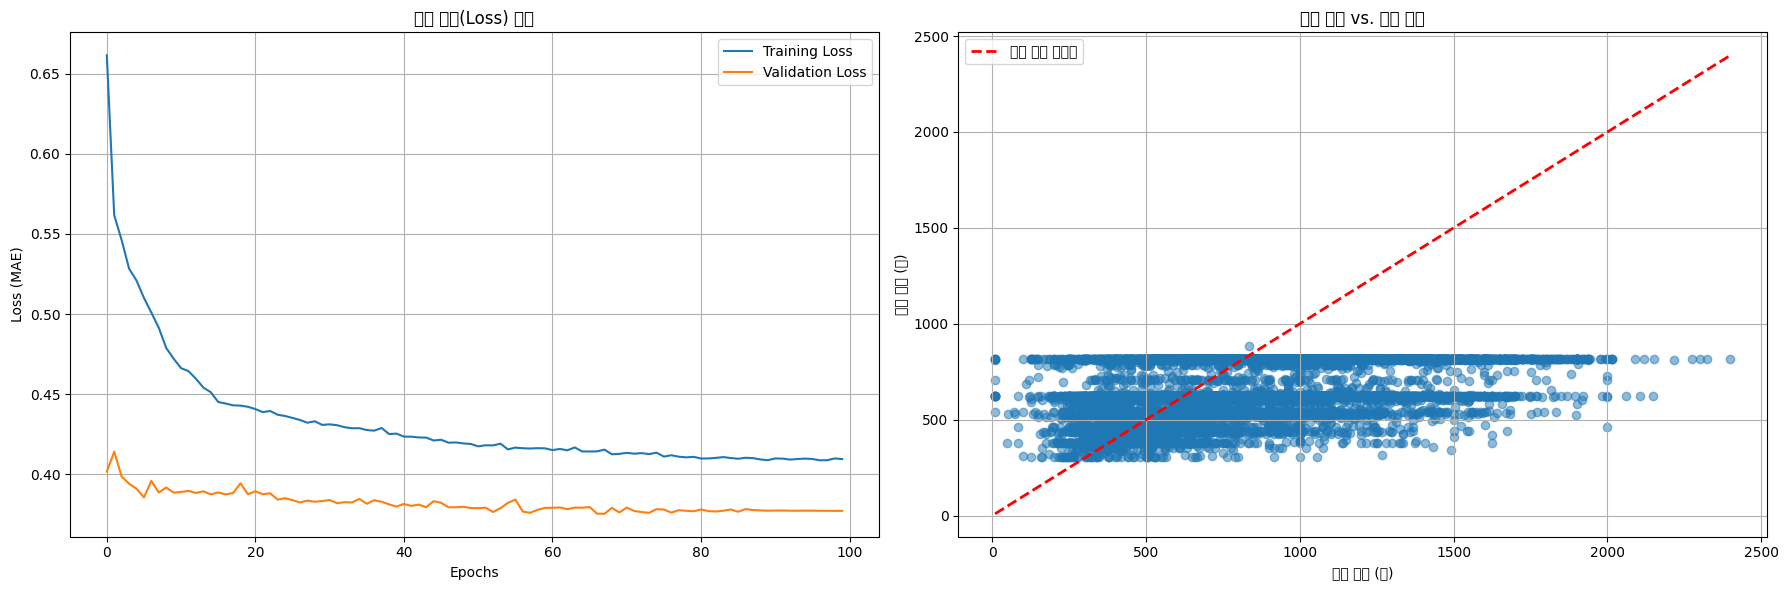

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import datetime
import os

# --- 1. 하이퍼파라미터 및 주요 설정 ---
LSTM_UNITS = 128
DROPOUT_RATE = 0.2
EPOCHS = 500
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
EARLY_STOPPING_PATIENCE = 40
SAVING_FOLDER = 'models/final_model_checkpoints/'

if not os.path.exists(SAVING_FOLDER):
    os.makedirs(SAVING_FOLDER)


# --- 1. 모델 입력을 위한 데이터 분리 ---
# X_train_seq에서 '직팜산지코드_encoded' 컬럼과 나머지 피처를 분리합니다.

# '직팜산지코드_encoded' 컬럼의 인덱스 찾기
categorical_feature_name = '직팜산지코드_encoded'
cat_feature_index = feature_cols.index(categorical_feature_name)

# 범주형(임베딩용) 데이터
X_train_cat = X_train_seq[:, :, cat_feature_index]
X_test_cat = X_test_seq[:, :, cat_feature_index]

# 연속형(나머지) 데이터
X_train_num = np.delete(X_train_seq, cat_feature_index, axis=2)
X_test_num = np.delete(X_test_seq, cat_feature_index, axis=2)

print("✅ 모델 입력을 위한 데이터 분리 완료")
print(f"범주형 데이터 Shape: {X_train_cat.shape}")
print(f"연속형 데이터 Shape: {X_train_num.shape}")

# --- 2. 하이퍼파라미터 및 모델 구축 (Functional API) ---
# 임베딩 설정
NUM_CATEGORIES = len(label_encoder.classes_)  # 고유한 산지 코드의 개수
EMBEDDING_DIM = 10  # 임베딩 벡터의 차원 (하이퍼파라미터)

# 모델의 입력층 정의
cat_input = Input(shape=(TIMESTEPS,), name='categorical_input')
num_input = Input(shape=(TIMESTEPS, X_train_num.shape[2]), name='numerical_input')

# 임베딩 레이어
embedding = Embedding(input_dim=NUM_CATEGORIES, output_dim=EMBEDDING_DIM, name='embedding_layer')(cat_input)

# 임베딩 벡터와 연속형 피처 결합
merged = Concatenate(name='concatenated_features')([embedding, num_input])

# LSTM 및 출력층
lstm_layer = LSTM(units=128, activation='tanh')(merged)
dropout_layer = Dropout(0.2)(lstm_layer)
output = Dense(units=1, name='output')(dropout_layer)

# 모델 생성
model = Model(inputs=[cat_input, num_input], outputs=output)

optimizer = tf.keras.optimizers.Adam(clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mae')
model.summary()

# --- 3. 모델 학습 ---
# 콜백 설정 (이전과 동일)
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_filepath = SAVING_FOLDER+f'best_model_emb_{item}_{current_time}.keras'
# ... (이전 답변의 콜백 설정 코드와 동일하게 사용)
checkpoint_cb = ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_loss', mode='min', save_best_only=True, verbose=1)
early_stopping_cb = EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)


# ⚠️ 모델 fit 함수에 입력을 리스트 형태로 전달합니다: [범주형, 연속형]
history = model.fit(
    [X_train_cat, X_train_num], y_train_seq,
    epochs=100, # 예시로 줄임
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

# --- 4. 모델 평가 및 결과 분석 ---
best_model = tf.keras.models.load_model(checkpoint_filepath)

# ⚠️ 모델 predict 함수에도 입력을 리스트 형태로 전달합니다.
y_pred_log = best_model.predict([X_test_cat, X_test_num]).flatten()

# 결과 분석용 DataFrame 생성 (이전과 동일)
results_df = keys_test.copy()
results_df['실제값_log'] = y_test_seq
results_df['예측값_log'] = y_pred_log
results_df['실제단가'] = np.expm1(results_df['실제값_log'])
results_df['예측단가'] = np.expm1(results_df['예측값_log'])

# 평가지표 계산 (이전과 동일)
mae = mean_absolute_error(results_df['실제단가'], results_df['예측단가'])
r2 = r2_score(results_df['실제단가'], results_df['예측단가'])

print("\n" + "="*50)
print("✅ 임베딩 모델 최종 평가 결과 (원래 스케일 기준)")
print("="*50)
print(f"MAE (Mean Absolute Error): {mae:.2f} 원")
print(f"R² Score: {r2:.4f}")
print("="*50)

# --- 5. 학습 과정 및 결과 시각화 ---
# Loss 그래프
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('모델 손실(Loss) 변화')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(True)

# 실제값 vs 예측값 Scatter Plot
plt.subplot(1, 2, 2)
plt.scatter(results_df['실제단가'], results_df['예측단가'], alpha=0.5)
min_val = min(results_df['실제단가'].min(), results_df['예측단가'].min())
max_val = max(results_df['실제단가'].max(), results_df['예측단가'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='완벽 예측 기준선')
plt.title('실제 단가 vs. 예측 단가')
plt.xlabel('실제 단가 (원)')
plt.ylabel('예측 단가 (원)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Matplotlib 한글 폰트 설정 (설치된 폰트에 맞게 수정)
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False


# ==============================================================================
# ## 🚀 주요 설정
# ==============================================================================
# 학습 시 사용했던 변수 (예시)
item = '무'
TARGET_COL = '평균단가(원)'

SAVING_FOLDER = 'final_model_checkpoints'
MODEL_PATH = os.path.join(SAVING_FOLDER, f'best_model{item}.keras')


# ==============================================================================
# ## 1. 테스트 데이터 및 모델 불러오기
# ==============================================================================
# 최종 전처리된 테스트 데이터를 불러옵니다.
try:
    test_df = pd.read_csv(file_path+f'test_processed_{item}.csv')
    print("✅ 테스트 데이터를 성공적으로 불러왔습니다.")
except FileNotFoundError:
    print(f"❌ 오류: 'test_processed_{item}.csv' 파일을 찾을 수 없습니다.")
    exit()

# 최적의 가중치를 가진 모델을 불러옵니다.
try:
    model = load_model(MODEL_PATH)
    print(f"✅ 모델 '{MODEL_PATH}'를 성공적으로 불러왔습니다.")
except Exception as e:
    print(f"❌ 오류: 모델을 불러오는 중 문제가 발생했습니다. {e}")
    exit()

# ==============================================================================
# ## 2. 테스트 데이터 준비
# ==============================================================================
# 피처(X)와 타겟(y) 분리 및 NumPy 배열로 변환
X_test = test_df.drop(columns=[TARGET_COL]).values
y_test = test_df[TARGET_COL].values # 로그 변환된 상태의 y값

# LSTM 입력 형태(3D)로 변환 (학습 때와 동일한 형태로)
X_test_3d = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
print(f"➡️ LSTM 입력 데이터 형태 변환 완료: {X_test_3d.shape}")


# ==============================================================================
# ## 3. 예측 및 결과 평가
# ==============================================================================
# 모델 예측 수행
y_pred = model.predict(X_test_3d).flatten()

# --- ⚠️ 중요: 로그 변환된 값들을 원래 스케일로 복원 ---
# 전처리 시 np.log1p()를 사용했으므로, np.expm1()로 복원합니다.
# y_test_original = np.expm1(y_test_log)
# y_pred_original = np.expm1(y_pred_log)

# 평가 지표 계산
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("✅ 최종 모델 평가 결과")
print("="*50)
print(f"MAE (Mean Absolute Error): {mae:.2f} 원")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} 원")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f} %")
print(f"R² Score: {r2:.4f}")
print("="*50)


# ==============================================================================
# ## 4. 결과 시각화
# ==============================================================================
plt.figure(figsize=(5, 5)) # 정사각형으로 만들면 기준선 보기가 더 편합니다.
sns.scatterplot(x=y_test, y=y_pred,alpha=0.6)

# --- [수정] y=x 기준선 그리기 ---
# 전체 데이터의 최소/최대값을 기준으로 선을 그어야 정확합니다.
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='완벽 예측 기준선 (y=x)')
# -----------------------------

plt.title('실제 값 vs. 예측 값 비교', fontsize=16)
plt.xlabel('실제 평균 단가 (원)', fontsize=14)
plt.ylabel('예측 평균 단가 (원)', fontsize=14)
plt.grid(True)
plt.legend() # label을 추가했으므로 범례가 잘 나타납니다.
plt.show()

NameError: name 'gdrive_data' is not defined

In [ ]:
a

# LSTM 3차

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


# --- 1. 데이터 로딩 및 전처리 ---
# 이 부분은 이전과 동일합니다.
df = pd.read_csv(gdrive_data+'배추_월차_집계가공.csv')
TARGET_COL = '평균단가(원)'
# 시간 순서가 중요하므로, 그룹과 시간으로 데이터를 명확히 정렬합니다.
df.sort_values(by=['직팜산지코드', '품종코드', 'year', 'week'], inplace=True)

df['총거래량(kg)'] = np.log1p(df['총거래량(kg)'])
df['week_sin'] = np.sin(2 * np.pi * df['week']/52.0)
df['week_cos'] = np.cos(2 * np.pi * df['week']/52.0)
df.dropna(inplace=True)
le_sanji = LabelEncoder()
le_pumjong = LabelEncoder()
df['직팜산지코드_le'] = le_sanji.fit_transform(df['직팜산지코드'])
df['품종코드_le'] = le_pumjong.fit_transform(df['품종코드'])

# --- 2. 스케일링 ---
cols_to_exclude = ['year', 'week', '직팜산지코드', '품종코드', '직팜산지코드_le', '품종코드_le', TARGET_COL]
num_cols = [c for c in df.columns if c not in cols_to_exclude]
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# --- 3. 그룹별 시퀀스 생성 ---
TIME_STEPS = 52
sanji_col = '직팜산지코드_le'
pumjong_col = '품종코드_le'
feature_cols = num_cols

# 그룹별로 시퀀스를 생성하는 함수
def create_grouped_sequences(df, feature_cols, target_col, group_cols, time_steps):
    # (이전 답변의 함수와 동일)
    all_Xs, all_sanjis, all_pumjongs, all_ys, all_keys = [], [], [], [], []
    for _, group_df in df.groupby(group_cols):
        if len(group_df) <= time_steps: continue
        X_group = group_df[feature_cols].values
        y_group = group_df[target_col].values
        sanji_idx_group = group_df[sanji_col].values
        pumjong_idx_group = group_df[pumjong_col].values
        key_group = group_df[['year', 'week', sanji_col, pumjong_col]].values

        for i in range(len(X_group) - time_steps):
            all_Xs.append(X_group[i:i+time_steps])
            all_sanjis.append(sanji_idx_group[i:i+time_steps])
            all_pumjongs.append(pumjong_idx_group[i:i+time_steps])
            all_ys.append(y_group[i+time_steps])
            all_keys.append(key_group[i+time_steps]) # y값 시점의 키 저장

    return np.array(all_Xs), np.array(all_sanjis), np.array(all_pumjongs), np.array(all_ys), np.array(all_keys)

# 전체 데이터를 이용해 시퀀스를 먼저 생성
all_X, all_sanji, all_pumjong, all_y, all_keys = create_grouped_sequences(df, feature_cols, TARGET_COL, [sanji_col, pumjong_col], TIME_STEPS)

# --- 4. [수정됨] 데이터를 시간순으로 훈련/검증/테스트 분할 ---
n_total = len(all_X)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.85)

# 훈련 세트 (전체의 0% ~ 70%)
X_train, sanji_train, pumjong_train, y_train = all_X[:n_train], all_sanji[:n_train], all_pumjong[:n_train], all_y[:n_train]

# 검증 세트 (전체의 70% ~ 85%)
X_val, sanji_val, pumjong_val, y_val = all_X[n_train:n_val], all_sanji[n_train:n_val], all_pumjong[n_train:n_val], all_y[n_train:n_val]

# 테스트 세트 (전체의 85% ~ 100%) - 가장 최신 데이터
X_test, sanji_test, pumjong_test, y_test, keys_test = all_X[n_val:], all_sanji[n_val:], all_pumjong[n_val:], all_y[n_val:], all_keys[n_val:]

print(f"총 시퀀스 수: {n_total}")
print(f"훈련 데이터 shape: {X_train.shape}, {y_train.shape}")
print(f"검증 데이터 shape: {X_val.shape}, {y_val.shape}")
print(f" 테스트 데이터 shape: {X_test.shape}, {y_test.shape}")

# --- 5. 모델 정의 및 학습 ---
class CastToFloat32(Layer):
    def call(self, inputs): return tf.cast(inputs, dtype=tf.float32)

input_seq = Input(shape=(TIME_STEPS, X_train.shape[2]), name='input_seq')
input_sanji = Input(shape=(TIME_STEPS,), name='input_sanji')
input_pumjong = Input(shape=(TIME_STEPS,), name='input_pumjong')
n_sanji = df[sanji_col].nunique()
n_pumjong = df[pumjong_col].nunique()

sanji_emb = Embedding(input_dim=n_sanji, output_dim=8)(input_sanji)
pumjong_emb = Embedding(input_dim=n_pumjong, output_dim=4)(input_pumjong)
x = Concatenate(axis=-1)([input_seq, CastToFloat32()(sanji_emb), CastToFloat32()(pumjong_emb)])
x = LSTM(128, return_sequences=True)(x)  # 1층: 모든 시점의 결과를 다음 층으로 전달
x = Dropout(0.3)(x)                      # 각 LSTM 층 뒤에 Dropout을 추가하면 과적합 방지에 효과적
x = LSTM(64)(x)                          # 2층 (마지막 층): 최종 요약만 Dense 층으로 전달
x = Dropout(0.3)(x)
output = Dense(1)(x)

model = Model(inputs=[input_seq, input_sanji, input_pumjong], outputs=output)
# Huber 손실 함수를 정의하고 컴파일합니다.
huber_loss = tf.keras.losses.Huber()
model.compile(optimizer='adam', loss=huber_loss, metrics=['mae'])
model.summary()


early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(gdrive_model+f'best_lstm_{item}.h5', monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    [X_train, sanji_train, pumjong_train], y_train,
    validation_data=([X_val, sanji_val, pumjong_val], y_val),
    epochs=500,
    batch_size=128,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# --- 6. 최종 평가 및 결과 확인 ---
y_pred = model.predict( [X_test, sanji_test, pumjong_test]).flatten()
result_df = pd.DataFrame(keys_test, columns=['year', 'week', '직팜산지코드_le', '품종코드_le'])
result_df['y_true'] = y_test
result_df['y_pred'] = y_pred

# 최종 모델 저장
model.save(gdrive_model + f'final_lstm_{item}.h5')

# 결과 데이터프레임 저장
result_df.to_csv(gdrive_data + f'prediction_results_{item}.csv', index=False)

# --- 예측 및 평가지표 ---
y_pred = model.predict([X_test, sanji_test, pumjong_test]).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} 원")
print(f"RMSE: {rmse:.2f} 원")
print(f"MAPE: {mape:.2f} %")
print(f"R² Score: {r2:.3f}")

총 시퀀스 수: 47986
훈련 데이터 shape: (33590, 52, 30), (33590,)
검증 데이터 shape: (7198, 52, 30), (7198,)
 테스트 데이터 shape: (7198, 52, 30), (7198,)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sanji         │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_pumjong       │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 52, 8)     │      1,320 │ input_sanji[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 52, 4)     │         20 │ input_pumjong[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_seq           │ (None, 52, 30)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_to_float32_6   │ (None, 52, 8)     │          0 │ embedding_6[0][0] │
│ (CastToFloat32)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_to_float32_7   │ (None, 52, 4)     │          0 │ embedding_7[0][0] │
│ (CastToFloat32)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 52, 42)    │          0 │ input_seq[0][0],  │
│ (Concatenate)       │                   │            │ cast_to_float32_… │
│                     │                   │            │ cast_to_float32_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 52, 128)   │     87,552 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 52, 128)   │          0 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 64)        │     49,408 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 138,365 (540.49 KB)

 Trainable params: 138,365 (540.49 KB)

...

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 329.7601 - mae: 330.2593 - val_loss: 517.7985 - val_mae: 518.2982
Epoch 196/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 333.3658 - mae: 333.8653
Epoch 196: val_loss did not improve from 517.79846
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 333.3578 - mae: 333.8573 - val_loss: 536.2605 - val_mae: 536.7603
Epoch 197/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 327.7358 - mae: 328.2353
Epoch 197: val_loss did not improve from 517.79846
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 327.7493 - mae: 328.2487 - val_loss: 524.7634 - val_mae: 525.2632
Epoch 198/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 324.3824 - mae: 324.8820
Epoch 198: val_loss did not improve from 517.79846
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 324.4684 - mae: 324.9679 - val_loss: 523.6874 - val_mae: 524.1871
Epoch 199/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 329.1415 - mae: 329.6408
Epoch 199: val_loss did not imp

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 323.8871 - mae: 324.3866 - val_loss: 516.9436 - val_mae: 517.4434
Epoch 203/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 317.2979 - mae: 317.7972
Epoch 203: val_loss improved from 516.94360 to 516.75598, saving model to /content/drive/MyDrive/박진성/best_lstm_배추.h5


263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 317.3715 - mae: 317.8708 - val_loss: 516.7560 - val_mae: 517.2557
Epoch 204/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 320.6259 - mae: 321.1253
Epoch 204: val_loss did not improve from 516.75598
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 320.6234 - mae: 321.1227 - val_loss: 520.6421 - val_mae: 521.1419
Epoch 205/500
258/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 320.8548 - mae: 321.3542
Epoch 205: val_loss did not improve from 516.75598
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 320.8432 - mae: 321.3426 - val_loss: 524.9963 - val_mae: 525.4960
Epoch 206/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 319.3954 - mae: 319.8947
Epoch 206: val_loss did not improve from 516.75598
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 319.3786 - mae: 319.8778 - val_loss: 518.4282 - val_mae: 518.9277
Epoch 207/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 320.4604 - mae: 320.9599
Epoch 207: val_loss did not imp

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 314.1624 - mae: 314.6619 - val_loss: 511.5883 - val_mae: 512.0880
Epoch 210/500
258/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 317.1783 - mae: 317.6778
Epoch 210: val_loss did not improve from 511.58826
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 317.1388 - mae: 317.6382 - val_loss: 531.1053 - val_mae: 531.6052
Epoch 211/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 313.4534 - mae: 313.9527
Epoch 211: val_loss did not improve from 511.58826
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 313.4518 - mae: 313.9510 - val_loss: 528.2178 - val_mae: 528.7178
Epoch 212/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 308.8936 - mae: 309.3929
Epoch 212: val_loss did not improve from 511.58826
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 308.9598 - mae: 309.4590 - val_loss: 523.2512 - val_mae: 523.7512
Epoch 213/500
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 311.7500 - mae: 312.2493
Epoch 213: val_loss did not imp

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE: 644.67 원
RMSE: 1013.34 원
MAPE: 56.51 %
R² Score: 0.190


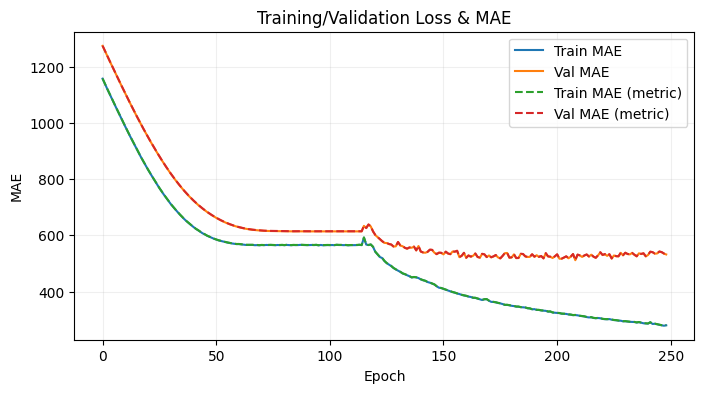

In [ ]:
import matplotlib.pyplot as plt

# 학습 결과 시각화

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train MAE')
plt.plot(history.history['val_loss'], label='Val MAE')
if 'mae' in history.history:
    plt.plot(history.history['mae'], '--', label='Train MAE (metric)')
if 'val_mae' in history.history:
    plt.plot(history.history['val_mae'], '--', label='Val MAE (metric)')
plt.title('Training/Validation Loss & MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


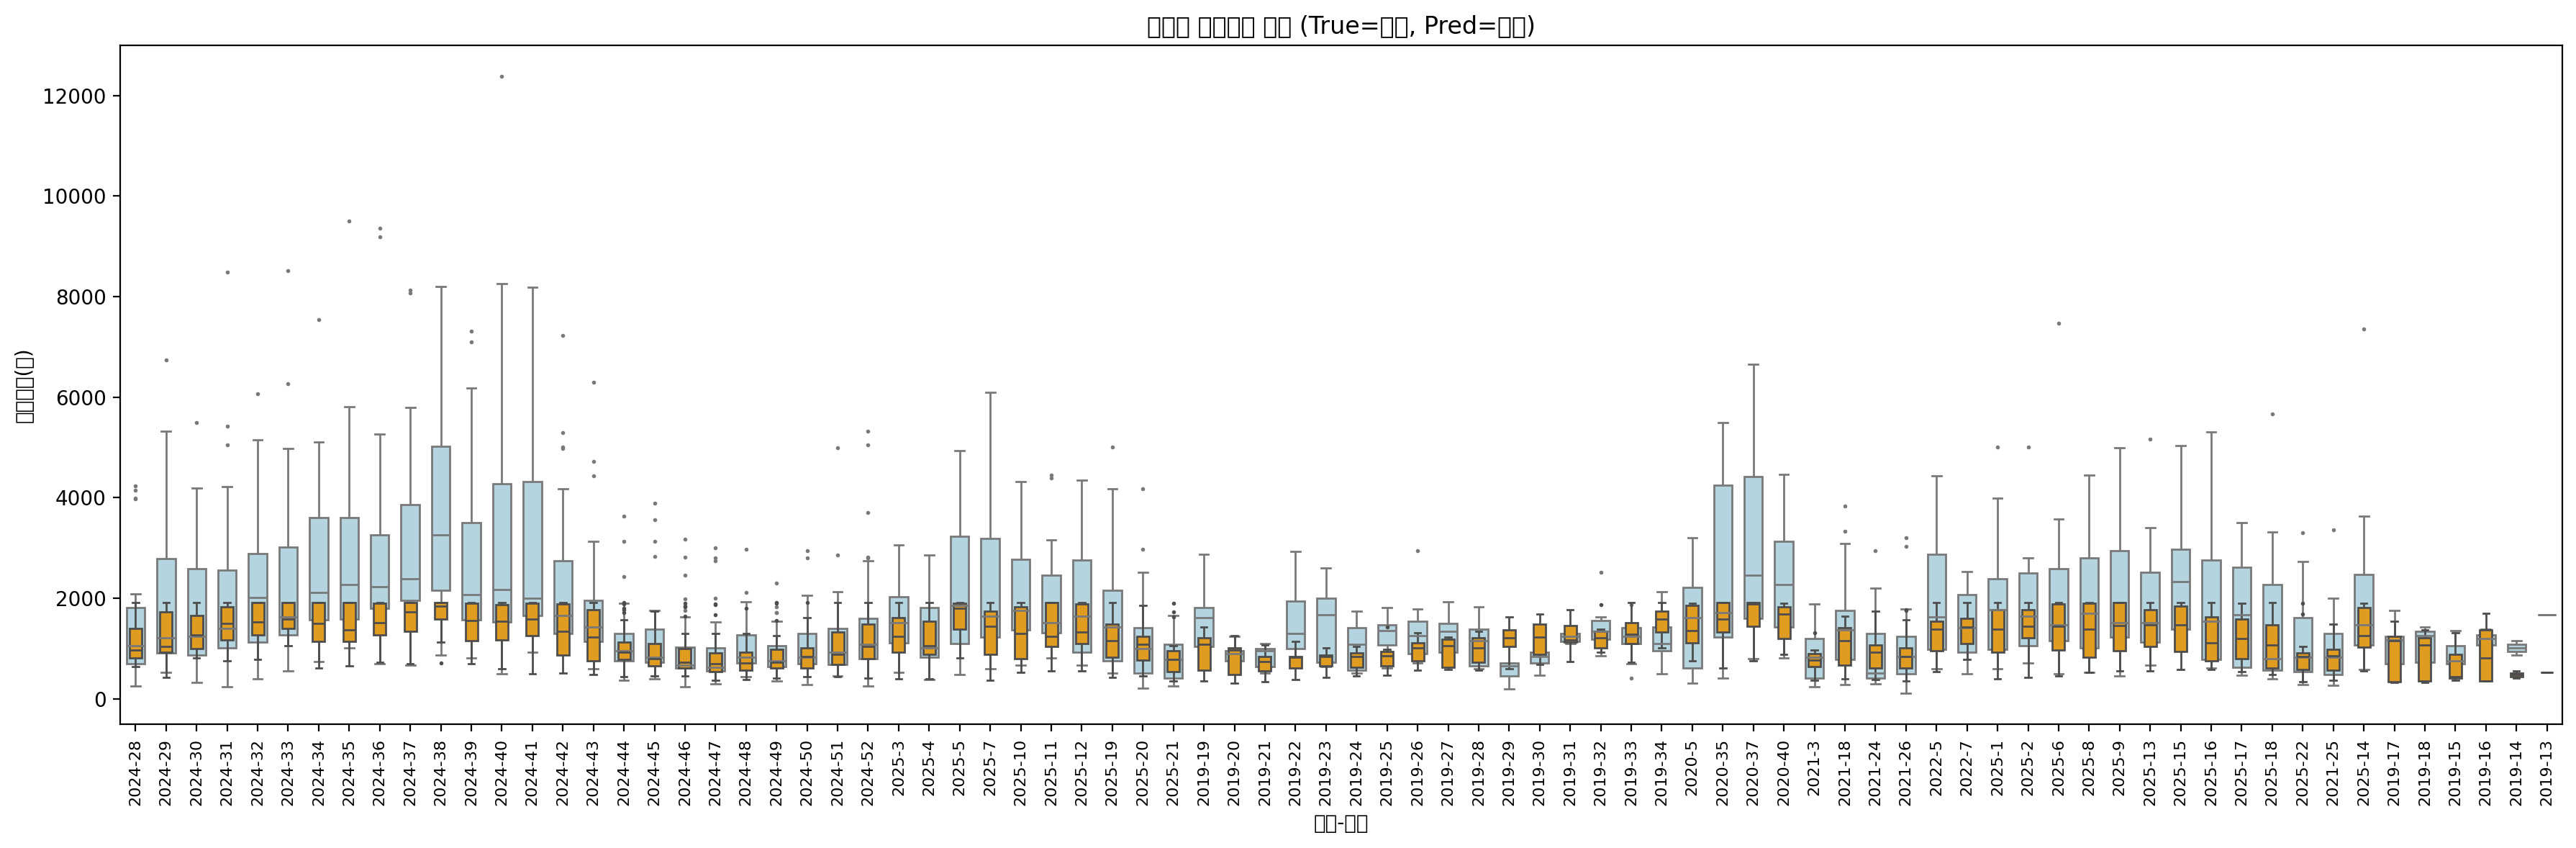

In [ ]:
# 박스플롯만 (실제/예측 분포)
import seaborn as sns

# (year, week) 문자열로 변환 (x축용)
result_df['year_week'] = result_df['year'].astype(int).astype(str) + '-' + result_df['week'].astype(int).astype(str)

# 최근 50~100주만 (너무 많으면 시각화 깨짐)
last_n = 80
unique_weeks = result_df['year_week'].unique()[-last_n:]
plot_df = result_df[result_df['year_week'].isin(unique_weeks)]

plt.figure(figsize=(18,6))
sns.boxplot(x='year_week', y='y_true', data=plot_df, color='lightblue', fliersize=1, width=0.6)
sns.boxplot(x='year_week', y='y_pred', data=plot_df, color='orange', fliersize=1, width=0.4)
plt.xticks(rotation=90, fontsize=8)
plt.title('주차별 평균단가 분포 (True=파랑, Pred=주황)')
plt.ylabel('평균단가(원)')
plt.xlabel('연도-주차')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 현재 설정 확인 (선택 사항)
print("현재 폰트 설정:", plt.rcParams['font.family'])
print("현재 마이너스 부호 설정:", plt.rcParams['axes.unicode_minus'])

# 모든 Matplotlib 설정을 기본값으로 초기화
mpl.rcdefaults()

# 초기화된 설정 확인
print("초기화 후 폰트 설정:", plt.rcParams['font.family'])
print("초기화 후 마이너스 부호 설정:", plt.rcParams['axes.unicode_minus'])

# 이제 Matplotlib은 기본 폰트 (대부분 영문 폰트)와 설정을 사용하게 됩니다.

현재 폰트 설정: ['NanumBarunGothic']
현재 마이너스 부호 설정: False
초기화 후 폰트 설정: ['sans-serif']
초기화 후 마이너스 부호 설정: True


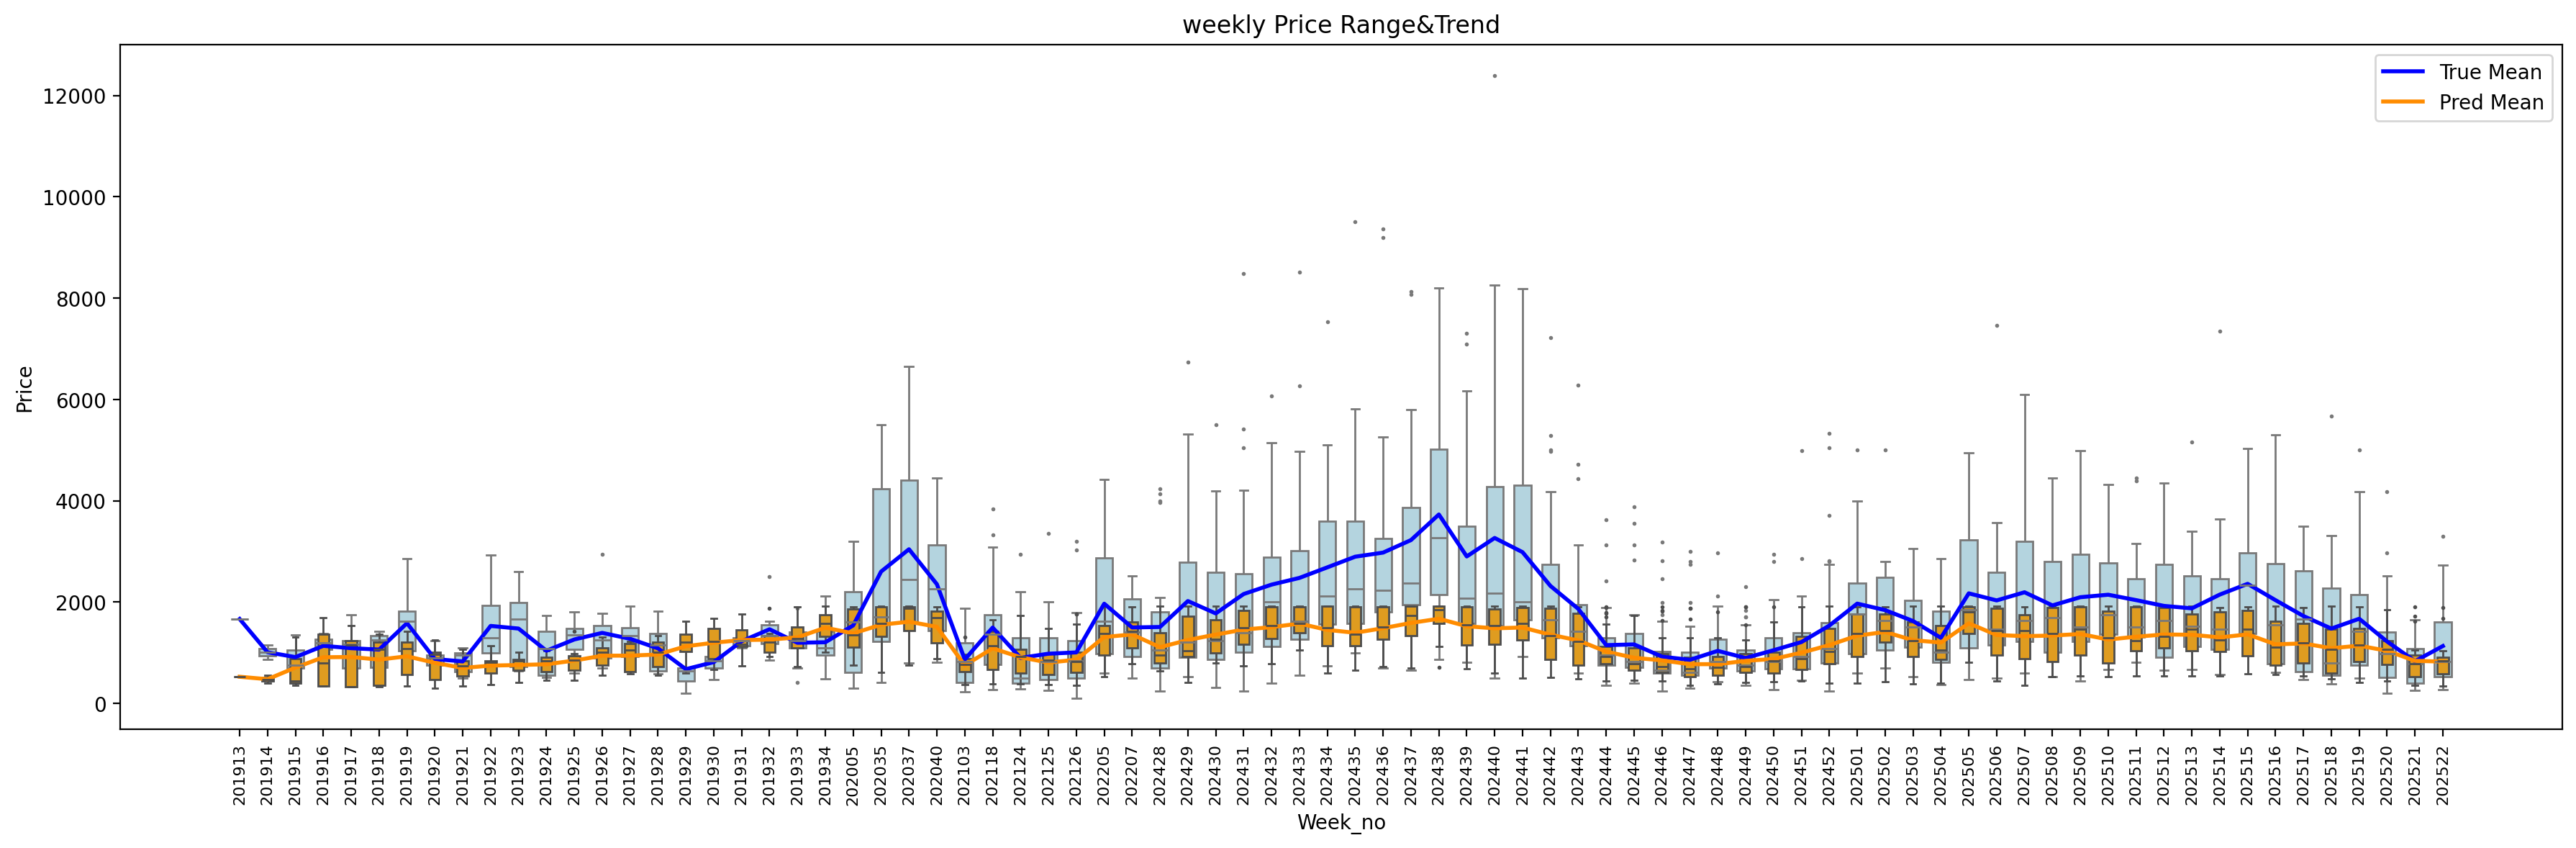

In [ ]:
# 박스플롯 + 선 그래프(평균 트렌드 동시 표시)
# 박스플롯
plot_df['week_no'] = plot_df['year'].astype(str) + plot_df['week'].astype(str).str.zfill(2)
plot_df['week_no'].astype(int)

plt.figure(figsize=(18,6))
sns.boxplot(x='week_no', y='y_true', data=plot_df, color='lightblue', fliersize=1, width=0.6)
sns.boxplot(x='week_no', y='y_pred', data=plot_df, color='orange', fliersize=1, width=0.4)

# 선 그래프(평균)
group_mean = plot_df.groupby('week_no')[['y_true', 'y_pred']].mean().reset_index()
group_mean = group_mean.sort_values('week_no').reset_index(drop=True) # Sort after calculating the mean

plt.plot(group_mean['week_no'], group_mean['y_true'], color='blue', label='True Mean', linewidth=2)
plt.plot(group_mean['week_no'], group_mean['y_pred'], color='darkorange', label='Pred Mean', linewidth=2)

plt.xticks(rotation=90, fontsize=8)
plt.title('weekly Price Range&Trend')
plt.ylabel('Price')
plt.xlabel('Week_no')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plot_df

,year,week,직팜산지코드_le,품종코드_le,y_true,y_pred,year_week,week_no
0,2019,13,156,4,1667.333333,527.695862,2019-13,201913
1,2019,14,156,0,874.000000,552.101746,2019-14,201914
2,2019,14,156,4,1148.666667,407.071930,2019-14,201914
3,2019,15,138,3,640.500000,1316.869507,2019-15,201915
4,2019,15,156,0,750.000000,442.002625,2019-15,201915
...,...,...,...,...,...,...,...,...
1566,2025,21,149,3,557.000000,856.883728,2025-21,202521
1567,2025,21,150,0,450.000000,526.641602,2025-21,202521
1568,2025,21,150,2,1062.333333,1624.033081,2025-21,202521
1569,2025,21,154,2,1000.000000,1902.312622,2025-21,202521


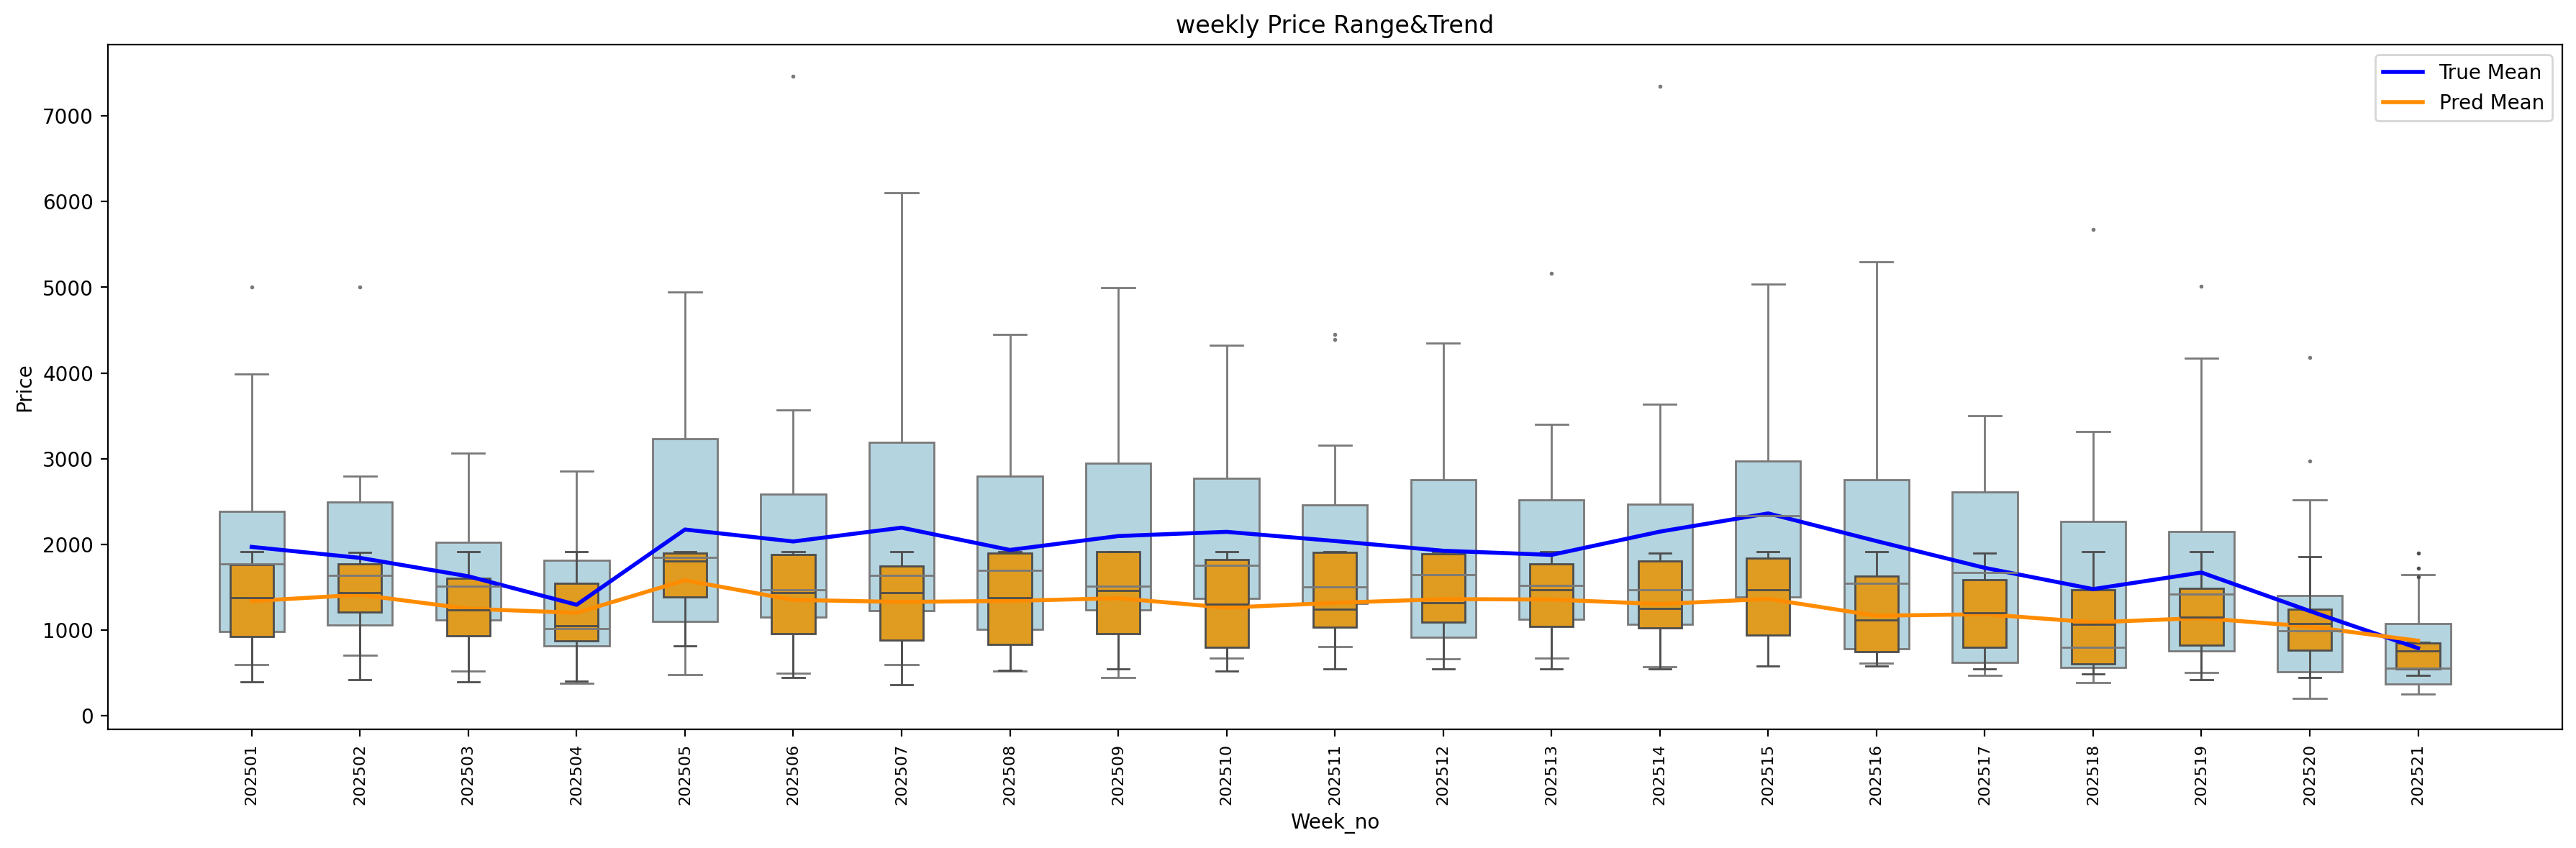

In [ ]:
# 박스플롯 + 선 그래프(평균 트렌드 동시 표시)
# 박스플롯
plot_df['week_no'] = plot_df['year'].astype(str) + plot_df['week'].astype(str).str.zfill(2)
plot_df['week_no'].astype(int)

plot_df_25 = plot_df[plot_df['year']==2025]

plt.figure(figsize=(18,6))
sns.boxplot(x='week_no', y='y_true', data=plot_df_25, color='lightblue', fliersize=1, width=0.6)
sns.boxplot(x='week_no', y='y_pred', data=plot_df_25, color='orange', fliersize=1, width=0.4)

# 선 그래프(평균)
group_mean = plot_df_25.groupby('week_no')[['y_true', 'y_pred']].mean().reset_index()
group_mean = group_mean.sort_values('week_no').reset_index(drop=True) # Sort after calculating the mean

plt.plot(group_mean['week_no'], group_mean['y_true'], color='blue', label='True Mean', linewidth=2)
plt.plot(group_mean['week_no'], group_mean['y_pred'], color='darkorange', label='Pred Mean', linewidth=2)

plt.xticks(rotation=90, fontsize=8)
plt.title('weekly Price Range&Trend')
plt.ylabel('Price')
plt.xlabel('Week_no')
plt.legend()
plt.tight_layout()
plt.show()

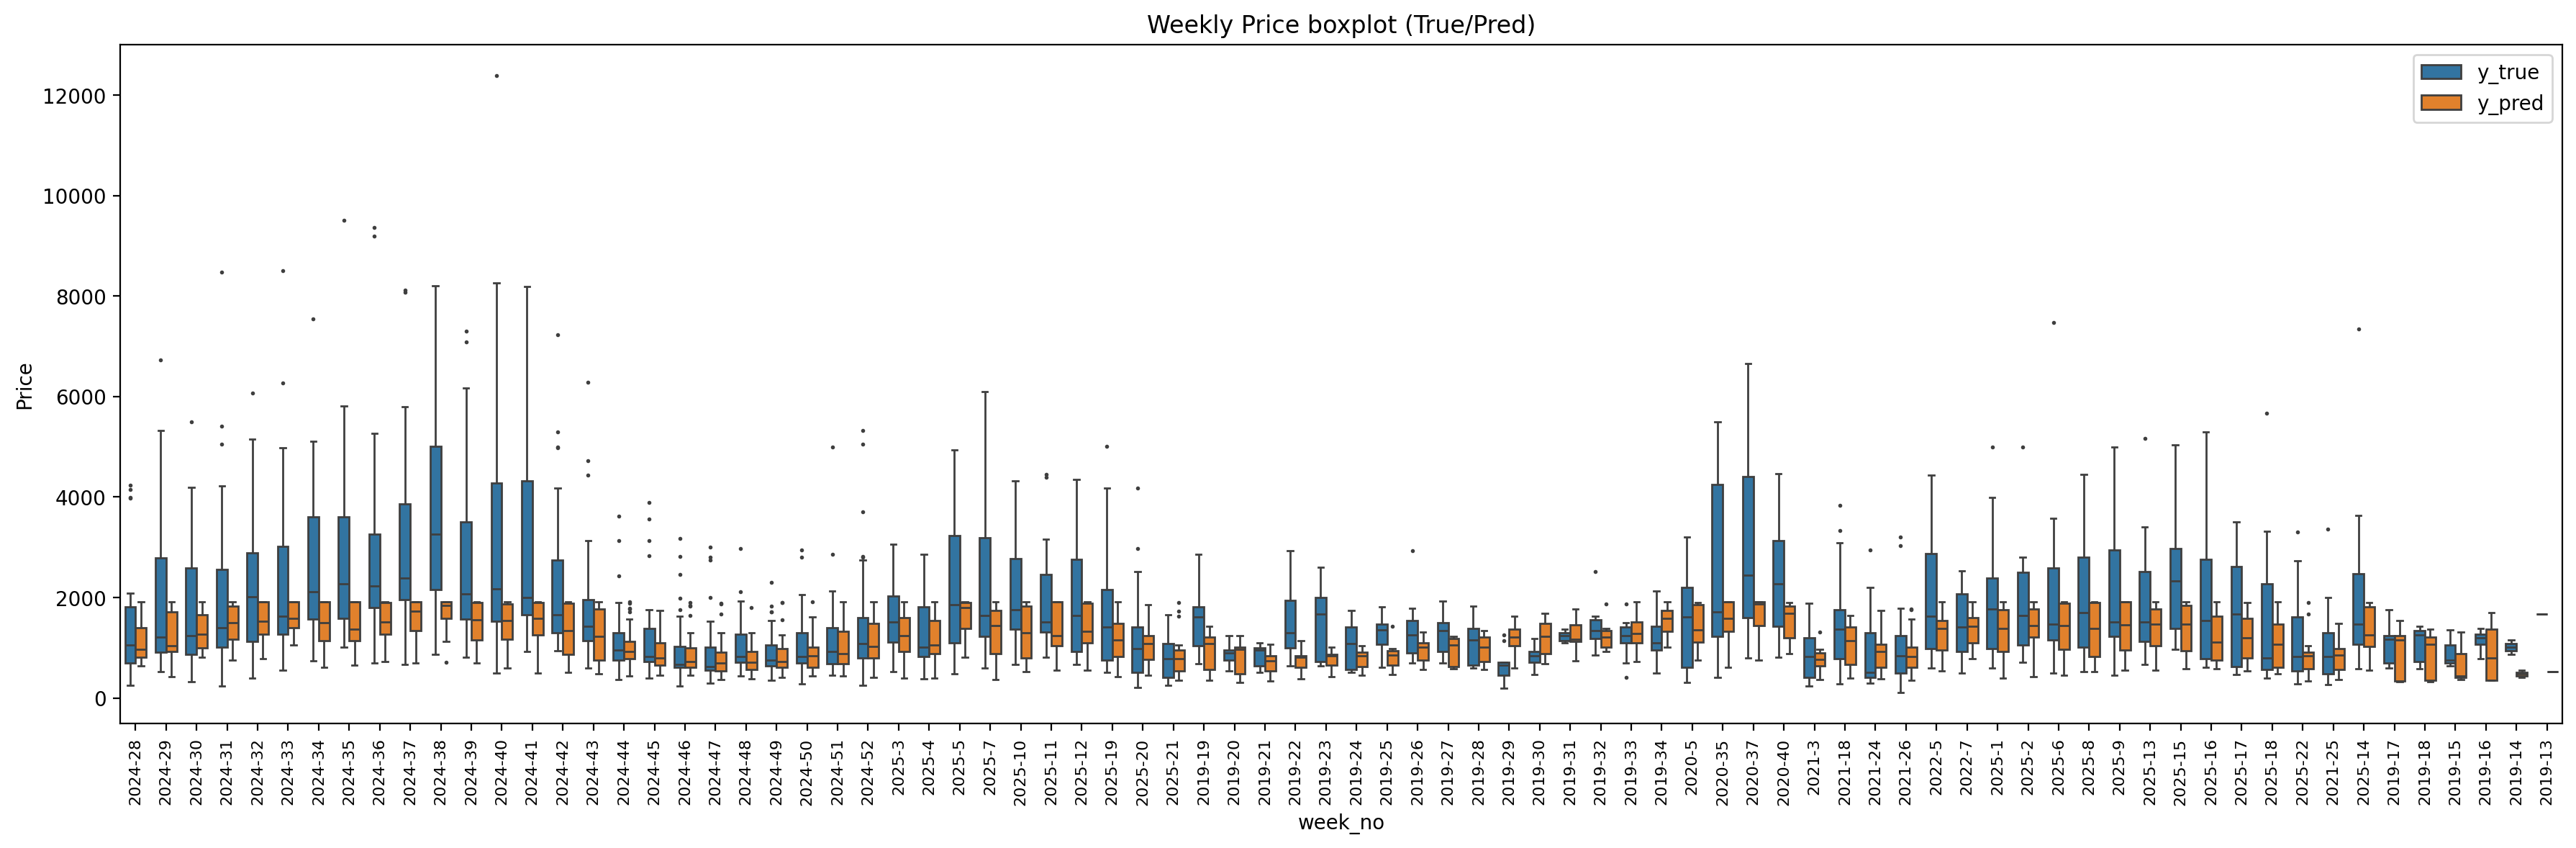

In [ ]:
# melt (long-form)
plot_df_melt = plot_df.melt(id_vars=['year_week'], value_vars=['y_true', 'y_pred'],
                            var_name='Type', value_name='Price')

plt.figure(figsize=(18,6))
sns.boxplot(x='year_week', y='Price', hue='Type', data=plot_df_melt,
            fliersize=1, width=0.7)
plt.xticks(rotation=90, fontsize=8)
plt.title('Weekly Price boxplot (True/Pred)')
plt.ylabel('Price')
plt.xlabel('week_no')
plt.legend()
plt.tight_layout()
plt.show()


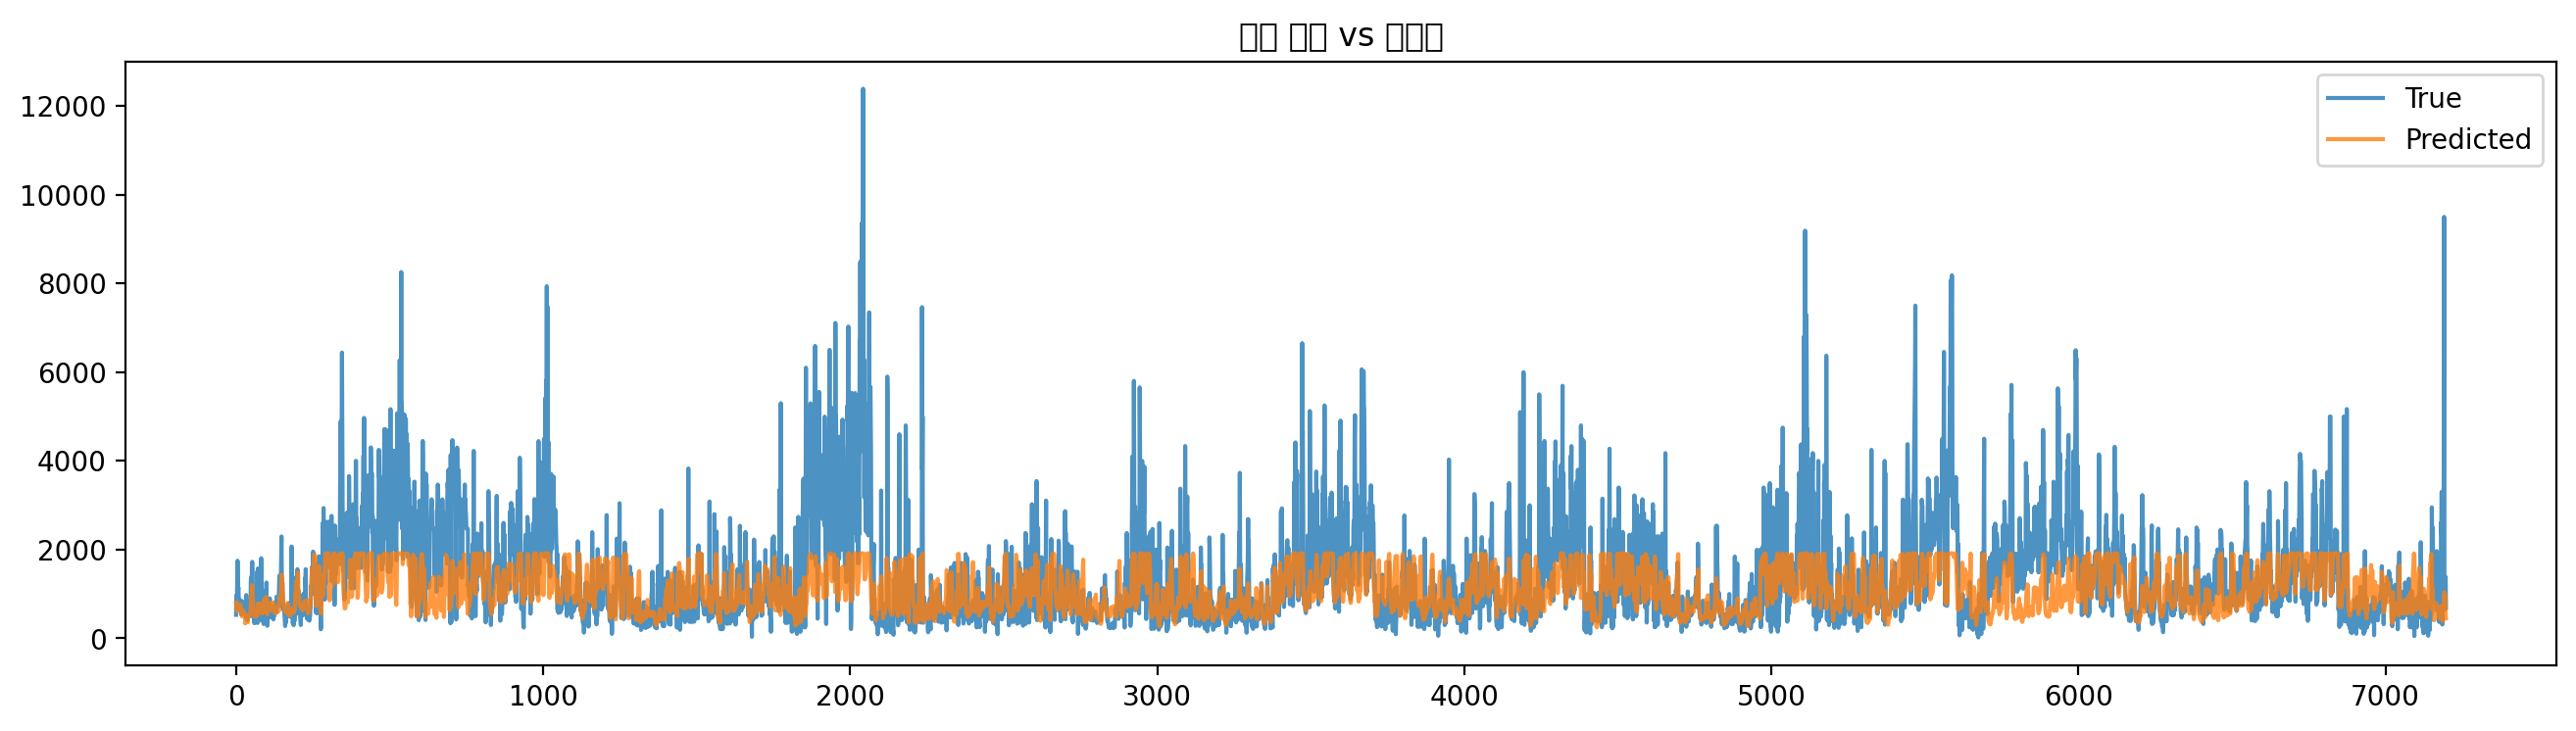

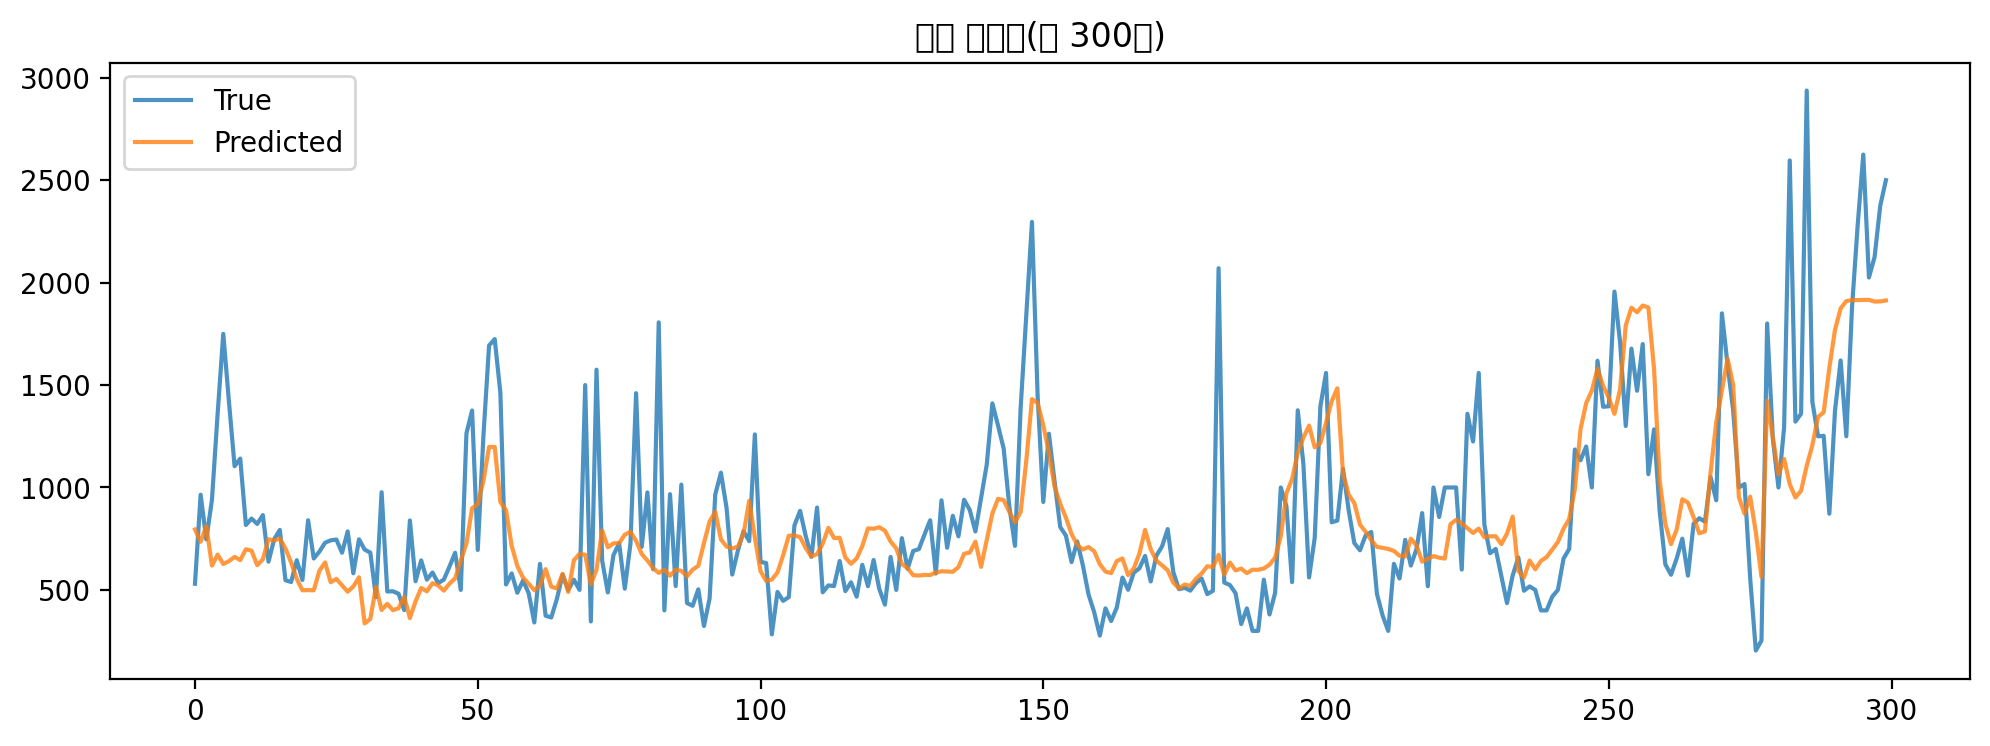

In [ ]:
# 전체 구간
plt.figure(figsize=(16,4))
plt.plot(y_test, label='True', alpha=0.8)
plt.plot(y_pred, label='Predicted', alpha=0.8)
plt.title('전체 예측 vs 실제값')
plt.legend()
plt.show()

# 일부 구간 확대 (예: 처음 300개)
plt.figure(figsize=(12,4))
plt.plot(y_test[:300], label='True', alpha=0.8)
plt.plot(y_pred[:300], label='Predicted', alpha=0.8)
plt.title('일부 시계열(앞 300개)')
plt.legend()
plt.show()


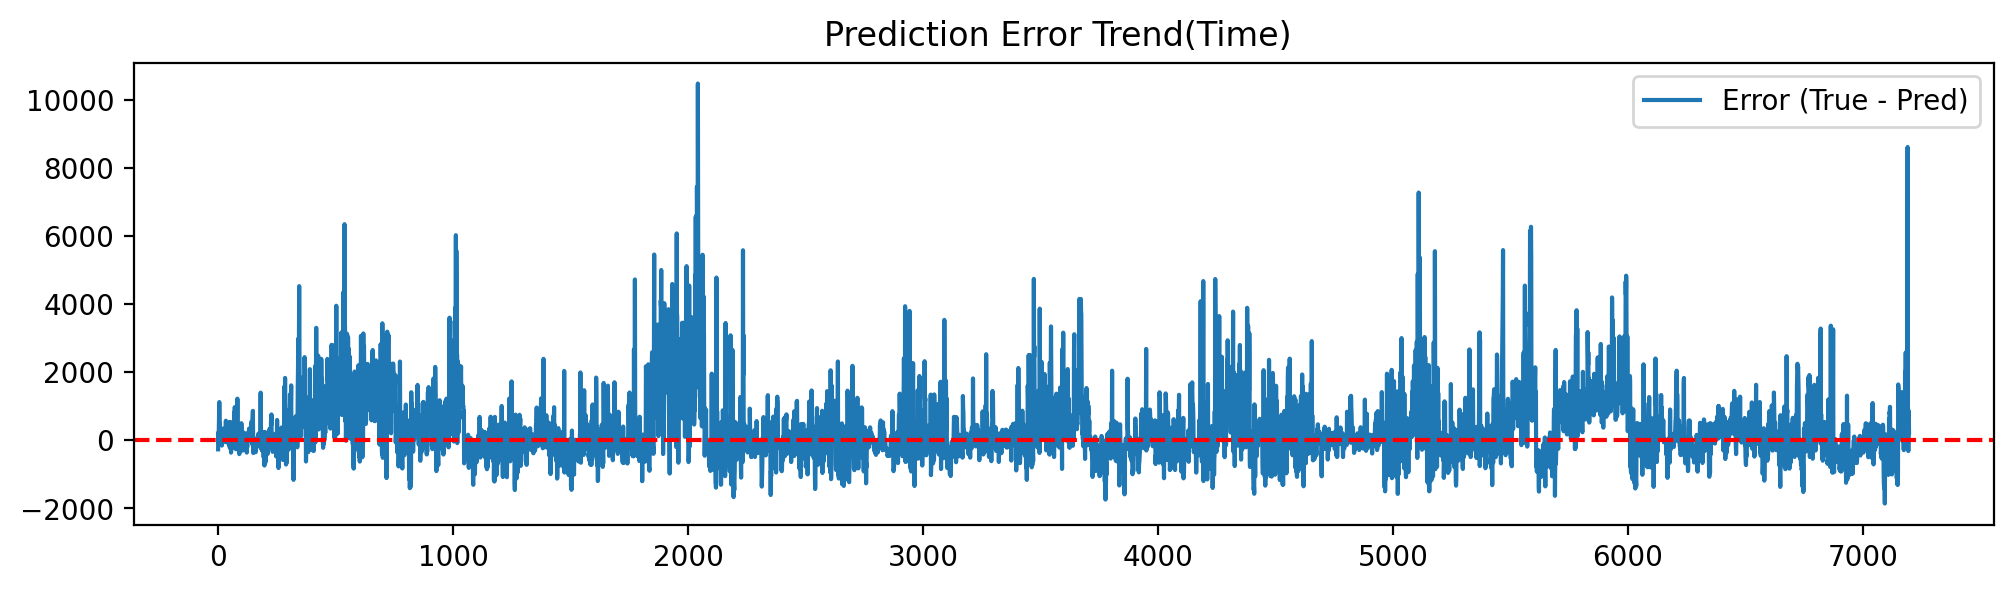

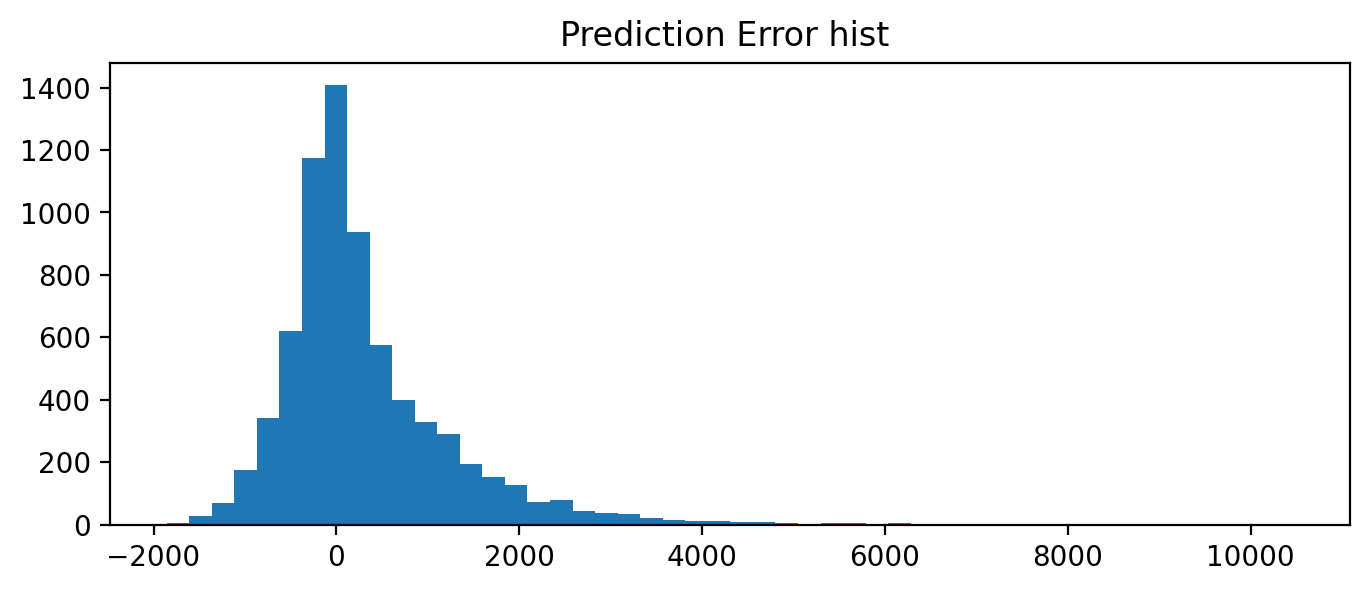

In [ ]:
# 예측 오차 시게열
errors = y_test - y_pred
plt.figure(figsize=(12,3))
plt.plot(errors, label='Error (True - Pred)')
plt.axhline(0, color='r', linestyle='--')
plt.title('Prediction Error Trend(Time) ')
plt.legend()
plt.show()

# 히스토그램
plt.figure(figsize=(8,3))
plt.hist(errors, bins=50)
plt.title('Prediction Error hist ')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import datetime
from sklearn.preprocessing import RobustScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate, Layer
from tensorflow.keras.layers import GlobalAveragePooling1D, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


# --- 1. 데이터 로딩 및 전처리 ---
# 이 부분은 이전과 동일합니다.
df = pd.read_csv(gdrive_data+'배추_월차_집계가공.csv')
TARGET_COL = '평균단가(원)'
# 시간 순서가 중요하므로, 그룹과 시간으로 데이터를 명확히 정렬합니다.
df.sort_values(by=['직팜산지코드', '품종코드', 'year', 'week'], inplace=True)

df['총거래량(kg)'] = np.log1p(df['총거래량(kg)'])
df['week_sin'] = np.sin(2 * np.pi * df['week']/52.0)
df['week_cos'] = np.cos(2 * np.pi * df['week']/52.0)
df.dropna(inplace=True)
le_sanji = LabelEncoder()
le_pumjong = LabelEncoder()
df['직팜산지코드_le'] = le_sanji.fit_transform(df['직팜산지코드'])
df['품종코드_le'] = le_pumjong.fit_transform(df['품종코드'])

# --- 2. 스케일링 ---
cols_to_exclude = ['year', 'week', '직팜산지코드', '품종코드', '직팜산지코드_le', '품종코드_le', TARGET_COL]
num_cols = [c for c in df.columns if c not in cols_to_exclude]
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# --- 3. 그룹별 시퀀스 생성 ---
TIME_STEPS = 52
sanji_col = '직팜산지코드_le'
pumjong_col = '품종코드_le'
feature_cols = num_cols

# 그룹별로 시퀀스를 생성하는 함수
def create_grouped_sequences(df, feature_cols, target_col, group_cols, time_steps):
    # (이전 답변의 함수와 동일)
    all_Xs, all_sanjis, all_pumjongs, all_ys, all_keys = [], [], [], [], []
    for _, group_df in df.groupby(group_cols):
        if len(group_df) <= time_steps: continue
        X_group = group_df[feature_cols].values
        y_group = group_df[target_col].values
        sanji_idx_group = group_df[sanji_col].values
        pumjong_idx_group = group_df[pumjong_col].values
        key_group = group_df[['year', 'week', sanji_col, pumjong_col]].values

        for i in range(len(X_group) - time_steps):
            all_Xs.append(X_group[i:i+time_steps])
            all_sanjis.append(sanji_idx_group[i:i+time_steps])
            all_pumjongs.append(pumjong_idx_group[i:i+time_steps])
            all_ys.append(y_group[i+time_steps])
            all_keys.append(key_group[i+time_steps]) # y값 시점의 키 저장

    return np.array(all_Xs), np.array(all_sanjis), np.array(all_pumjongs), np.array(all_ys), np.array(all_keys)

# 전체 데이터를 이용해 시퀀스를 먼저 생성
all_X, all_sanji, all_pumjong, all_y, all_keys = create_grouped_sequences(df, feature_cols, TARGET_COL, [sanji_col, pumjong_col], TIME_STEPS)

# --- 4. [수정됨] 데이터를 시간순으로 훈련/검증/테스트 분할 ---
n_total = len(all_X)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.85)

# 훈련 세트 (전체의 0% ~ 70%)
X_train, sanji_train, pumjong_train, y_train = all_X[:n_train], all_sanji[:n_train], all_pumjong[:n_train], all_y[:n_train]

# 검증 세트 (전체의 70% ~ 85%)
X_val, sanji_val, pumjong_val, y_val = all_X[n_train:n_val], all_sanji[n_train:n_val], all_pumjong[n_train:n_val], all_y[n_train:n_val]

# 테스트 세트 (전체의 85% ~ 100%) - 가장 최신 데이터
X_test, sanji_test, pumjong_test, y_test, keys_test = all_X[n_val:], all_sanji[n_val:], all_pumjong[n_val:], all_y[n_val:], all_keys[n_val:]

print(f"총 시퀀스 수: {n_total}")
print(f"훈련 데이터 shape: {X_train.shape}, {y_train.shape}")
print(f"검증 데이터 shape: {X_val.shape}, {y_val.shape}")
print(f" 테스트 데이터 shape: {X_test.shape}, {y_test.shape}")

# --- 5. 모델 정의 및 학습 ---
class CastToFloat32(Layer):
    def call(self, inputs): return tf.cast(inputs, dtype=tf.float32)

input_seq = Input(shape=(TIME_STEPS, X_train.shape[2]), name='input_seq')
input_sanji = Input(shape=(TIME_STEPS,), name='input_sanji')
input_pumjong = Input(shape=(TIME_STEPS,), name='input_pumjong')
n_sanji = df[sanji_col].nunique()
n_pumjong = df[pumjong_col].nunique()

sanji_emb = Embedding(input_dim=n_sanji, output_dim=8)(input_sanji)
pumjong_emb = Embedding(input_dim=n_pumjong, output_dim=4)(input_pumjong)
x = Concatenate(axis=-1)([input_seq, CastToFloat32()(sanji_emb), CastToFloat32()(pumjong_emb)])
x = LSTM(128, return_sequences=True)(x)  # 1층: 모든 시점의 결과를 다음 층으로 전달
x = Dropout(0.4)(x)                      # 각 LSTM 층 뒤에 Dropout을 추가하면 과적합 방지에 효과적
x = LSTM(64, return_sequences=True)(x)   # 2층 : 어텐션 층으로 전달
x = Dropout(0.3)(x)

# Attention 레이어 추가 -query와 value에 같은 값을 넣어 Self-Attention을 구현
attention_output = Attention()([x, x])

# Attention의 출력을 다시 1D 벡터로 변경
x = GlobalAveragePooling1D()(attention_output)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1)(x)

model = Model(inputs=[input_seq, input_sanji, input_pumjong], outputs=output)
# # Huber 손실 함수를 정의하고 컴파일합니다.
# huber_loss = tf.keras.losses.Huber()
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()


early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(gdrive_model+f'best_lstm_{item}.h5', monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    [X_train, sanji_train, pumjong_train], y_train,
    validation_data=([X_val, sanji_val, pumjong_val], y_val),
    epochs=500,
    batch_size=128,
    callbacks=[early_stop, checkpoint],
    verbose=2
)

# --- 6. 최종 평가 및 결과 확인 ---
y_pred = model.predict( [X_test, sanji_test, pumjong_test]).flatten()
result_df = pd.DataFrame(keys_test, columns=['year', 'week', '직팜산지코드_le', '품종코드_le'])
result_df['y_true'] = y_test
result_df['y_pred'] = y_pred

# --- 예측 및 평가지표 ---
y_pred = model.predict([X_test, sanji_test, pumjong_test]).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} 원")
print(f"RMSE: {rmse:.2f} 원")
print(f"MAPE: {mape:.2f} %")
print(f"R² Score: {r2:.3f}")

current_time = datetime.datetime.now()

# 최종 모델 저장
model.save(gdrive_model + f'final_lstm_{item}_mse-{mae:.2f}_r2-{r2:.3f}_RMSE-{rmse:.2f}_current_time.h5')

# 결과 데이터프레임 저장
result_df.to_csv(gdrive_data + f'prediction_results_{item}_current_time.csv', index=False)


총 시퀀스 수: 47986
훈련 데이터 shape: (33590, 52, 27), (33590,)
검증 데이터 shape: (7198, 52, 27), (7198,)
 테스트 데이터 shape: (7198, 52, 27), (7198,)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sanji         │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_pumjong       │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 52, 8)     │      1,320 │ input_sanji[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 52, 4)     │         20 │ input_pumjong[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_seq           │ (None, 52, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_to_float32     │ (None, 52, 8)     │          0 │ embedding[0][0]   │
│ (CastToFloat32)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_to_float32_1   │ (None, 52, 4)     │          0 │ embedding_1[0][0] │
│ (CastToFloat32)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 52, 39)    │          0 │ input_seq[0][0],  │
│ (Concatenate)       │                   │            │ cast_to_float32[… │
│                     │                   │            │ cast_to_float32_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 52, 128)   │     86,016 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 52, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 52, 64)    │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 52, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 52, 64)    │          0 │ dropout_1[0][0],  │
│ (Attention)         │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 138,877 (542.49 KB)

 Trainable params: 138,877 (542.49 KB)

...

263/263 - 3s - 11ms/step - loss: 499.2860 - mae: 499.2860 - val_loss: 547.4120 - val_mae: 547.4120
Epoch 9/500

Epoch 9: val_loss did not improve from 547.41199
263/263 - 3s - 10ms/step - loss: 491.7030 - mae: 491.7030 - val_loss: 555.1605 - val_mae: 555.1605
Epoch 10/500

Epoch 10: val_loss did not improve from 547.41199
263/263 - 3s - 10ms/step - loss: 483.9954 - mae: 483.9954 - val_loss: 550.8957 - val_mae: 550.8957
Epoch 11/500

Epoch 11: val_loss did not improve from 547.41199
263/263 - 3s - 10ms/step - loss: 474.3624 - mae: 474.3624 - val_loss: 550.0494 - val_mae: 550.0494
Epoch 12/500

Epoch 12: val_loss did not improve from 547.41199
263/263 - 3s - 10ms/step - loss: 472.6673 - mae: 472.6673 - val_loss: 551.0681 - val_mae: 551.0681
Epoch 13/500

Epoch 13: val_loss improved from 547.41199 to 545.71484, saving model to /content/drive/MyDrive/박진성/models/best_lstm_배추.h5


263/263 - 3s - 11ms/step - loss: 462.4530 - mae: 462.4530 - val_loss: 545.7148 - val_mae: 545.7148
Epoch 14/500

Epoch 14: val_loss improved from 545.71484 to 545.27637, saving model to /content/drive/MyDrive/박진성/models/best_lstm_배추.h5


263/263 - 3s - 11ms/step - loss: 454.6587 - mae: 454.6587 - val_loss: 545.2764 - val_mae: 545.2764
Epoch 15/500

Epoch 15: val_loss improved from 545.27637 to 526.57123, saving model to /content/drive/MyDrive/박진성/models/best_lstm_배추.h5


263/263 - 3s - 11ms/step - loss: 446.5466 - mae: 446.5466 - val_loss: 526.5712 - val_mae: 526.5712
Epoch 16/500

Epoch 16: val_loss did not improve from 526.57123
263/263 - 3s - 10ms/step - loss: 441.1594 - mae: 441.1594 - val_loss: 537.2033 - val_mae: 537.2033
Epoch 17/500

Epoch 17: val_loss did not improve from 526.57123
263/263 - 3s - 11ms/step - loss: 435.4588 - mae: 435.4588 - val_loss: 558.7487 - val_mae: 558.7487
Epoch 18/500

Epoch 18: val_loss did not improve from 526.57123
263/263 - 3s - 10ms/step - loss: 430.9732 - mae: 430.9732 - val_loss: 549.5696 - val_mae: 549.5696
Epoch 19/500

Epoch 19: val_loss did not improve from 526.57123
263/263 - 3s - 10ms/step - loss: 425.2942 - mae: 425.2942 - val_loss: 546.2209 - val_mae: 546.2209
Epoch 20/500

Epoch 20: val_loss did not improve from 526.57123
263/263 - 3s - 10ms/step - loss: 420.9605 - mae: 420.9605 - val_loss: 534.2139 - val_mae: 534.2139
Epoch 21/500

Epoch 21: val_loss did not improve from 526.57123
263/263 - 3s - 11ms/st

MAE: 678.79 원
RMSE: 1059.55 원
MAPE: 63.59 %
R² Score: 0.115


In [ ]:
import pandas as pd
import numpy as np
import datetime
from sklearn.preprocessing import RobustScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate, Layer
from tensorflow.keras.layers import GlobalAveragePooling1D, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import Huber
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


# --- 1. 데이터 로딩 및 전처리 ---
# 이 부분은 이전과 동일합니다.
df = pd.read_csv(gdrive_data+'배추_월차_집계가공.csv')
TARGET_COL = '평균단가(원)'
# 시간 순서가 중요하므로, 그룹과 시간으로 데이터를 명확히 정렬합니다.
df.sort_values(by=['직팜산지코드', '품종코드', 'year', 'week'], inplace=True)

df['총거래량(kg)'] = np.log1p(df['총거래량(kg)'])
df['week_sin'] = np.sin(2 * np.pi * df['week']/52.0)
df['week_cos'] = np.cos(2 * np.pi * df['week']/52.0)
df.dropna(inplace=True)
le_sanji = LabelEncoder()
le_pumjong = LabelEncoder()
df['직팜산지코드_le'] = le_sanji.fit_transform(df['직팜산지코드'])
df['품종코드_le'] = le_pumjong.fit_transform(df['품종코드'])

# --- 2. 스케일링 ---
cols_to_exclude = ['year', 'week', '직팜산지코드', '품종코드', '직팜산지코드_le', '품종코드_le', TARGET_COL]
num_cols = [c for c in df.columns if c not in cols_to_exclude]
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# --- 3. 그룹별 시퀀스 생성 ---
TIME_STEPS = 52
sanji_col = '직팜산지코드_le'
pumjong_col = '품종코드_le'
feature_cols = num_cols

# 그룹별로 시퀀스를 생성하는 함수
def create_grouped_sequences(df, feature_cols, target_col, group_cols, time_steps):
    # (이전 답변의 함수와 동일)
    all_Xs, all_sanjis, all_pumjongs, all_ys, all_keys = [], [], [], [], []
    for _, group_df in df.groupby(group_cols):
        if len(group_df) <= time_steps: continue
        X_group = group_df[feature_cols].values
        y_group = group_df[target_col].values
        sanji_idx_group = group_df[sanji_col].values
        pumjong_idx_group = group_df[pumjong_col].values
        key_group = group_df[['year', 'week', sanji_col, pumjong_col]].values

        for i in range(len(X_group) - time_steps):
            all_Xs.append(X_group[i:i+time_steps])
            all_sanjis.append(sanji_idx_group[i:i+time_steps])
            all_pumjongs.append(pumjong_idx_group[i:i+time_steps])
            all_ys.append(y_group[i+time_steps])
            all_keys.append(key_group[i+time_steps]) # y값 시점의 키 저장

    return np.array(all_Xs), np.array(all_sanjis), np.array(all_pumjongs), np.array(all_ys), np.array(all_keys)

# 전체 데이터를 이용해 시퀀스를 먼저 생성
all_X, all_sanji, all_pumjong, all_y, all_keys = create_grouped_sequences(df, feature_cols, TARGET_COL, [sanji_col, pumjong_col], TIME_STEPS)

# --- 4. [수정됨] 데이터를 시간순으로 훈련/검증/테스트 분할 ---
n_total = len(all_X)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.85)

# 훈련 세트 (전체의 0% ~ 70%)
X_train, sanji_train, pumjong_train, y_train = all_X[:n_train], all_sanji[:n_train], all_pumjong[:n_train], all_y[:n_train]

# 검증 세트 (전체의 70% ~ 85%)
X_val, sanji_val, pumjong_val, y_val = all_X[n_train:n_val], all_sanji[n_train:n_val], all_pumjong[n_train:n_val], all_y[n_train:n_val]

# 테스트 세트 (전체의 85% ~ 100%) - 가장 최신 데이터
X_test, sanji_test, pumjong_test, y_test, keys_test = all_X[n_val:], all_sanji[n_val:], all_pumjong[n_val:], all_y[n_val:], all_keys[n_val:]

print(f"총 시퀀스 수: {n_total}")
print(f"훈련 데이터 shape: {X_train.shape}, {y_train.shape}")
print(f"검증 데이터 shape: {X_val.shape}, {y_val.shape}")
print(f" 테스트 데이터 shape: {X_test.shape}, {y_test.shape}")

# --- 5. 모델 정의 및 학습 ---
class CastToFloat32(Layer):
    def call(self, inputs): return tf.cast(inputs, dtype=tf.float32)

input_seq = Input(shape=(TIME_STEPS, X_train.shape[2]), name='input_seq')
input_sanji = Input(shape=(TIME_STEPS,), name='input_sanji')
input_pumjong = Input(shape=(TIME_STEPS,), name='input_pumjong')
n_sanji = df[sanji_col].nunique()
n_pumjong = df[pumjong_col].nunique()

sanji_emb = Embedding(input_dim=n_sanji, output_dim=8)(input_sanji)
pumjong_emb = Embedding(input_dim=n_pumjong, output_dim=4)(input_pumjong)
x = Concatenate(axis=-1)([input_seq, CastToFloat32()(sanji_emb), CastToFloat32()(pumjong_emb)])
# x = LSTM(128, return_sequences=True)(x)  # 1층: 모든 시점의 결과를 다음 층으로 전달
# x = Dropout(0.4)(x)                      # 각 LSTM 층 뒤에 Dropout을 추가하면 과적합 방지에 효과적
x = LSTM(64, return_sequences=True)(x)   # 2층 : 어텐션 층으로 전달
x = Dropout(0.3)(x)

# Attention 레이어 추가 -query와 value에 같은 값을 넣어 Self-Attention을 구현
attention_output = Attention()([x, x])

# Attention의 출력을 다시 1D 벡터로 변경
x = GlobalAveragePooling1D()(attention_output)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1)(x)

model = Model(inputs=[input_seq, input_sanji, input_pumjong], outputs=output)
# # Huber 손실 함수를 정의하고 컴파일합니다.
# huber_loss = tf.keras.losses.Huber()
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
model.summary()


early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(gdrive_model+f'best_lstm_{item}.h5', monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    [X_train, sanji_train, pumjong_train], y_train,
    validation_data=([X_val, sanji_val, pumjong_val], y_val),
    epochs=500,
    batch_size=128,
    callbacks=[early_stop, checkpoint],
    verbose=2
)

# --- 6. 최종 평가 및 결과 확인 ---
y_pred = model.predict( [X_test, sanji_test, pumjong_test]).flatten()
result_df = pd.DataFrame(keys_test, columns=['year', 'week', '직팜산지코드_le', '품종코드_le'])
result_df['y_true'] = y_test
result_df['y_pred'] = y_pred

# --- 예측 및 평가지표 ---
y_pred = model.predict([X_test, sanji_test, pumjong_test]).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} 원")
print(f"RMSE: {rmse:.2f} 원")
print(f"MAPE: {mape:.2f} %")
print(f"R² Score: {r2:.3f}")

current_time = datetime.datetime.now()

# 최종 모델 저장
model.save(gdrive_model + f'final_lstm_{item}_mse-{mae:.2f}_r2-{r2:.3f}_RMSE-{rmse:.2f}_current_time.h5')

# 결과 데이터프레임 저장
result_df.to_csv(gdrive_data + f'prediction_results_{item}_current_time.csv', index=False)
